In [1]:
%pip install catboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv('/content/datatrain.csv')
test = pd.read_csv('/content/datatest.csv')
sub = pd.read_csv('/content/submission.csv')

# Data Cleaning

## Correcting Inconsistencies Data

In [4]:
# Define the columns to lowercase
columns_to_lowercase = ['conditions', 'seasons', 'holiday']

# Convert specified columns in train to lowercase, keeping NaN as is
for col in columns_to_lowercase:
    train[col] = train[col].apply(lambda x: x.lower() if isinstance(x, str) else x)

# Convert specified columns in test to lowercase, keeping NaN as is
for col in columns_to_lowercase:
    test[col] = test[col].apply(lambda x: x.lower() if isinstance(x, str) else x)

print("Lowercase conversion complete for 'conditions', 'seasons', and 'holiday' columns in both train and test datasets.")

Lowercase conversion complete for 'conditions', 'seasons', and 'holiday' columns in both train and test datasets.


In [5]:
# Convert 'yes' to True and 'no' to False in the 'holiday' column for train
train['holiday'] = train['holiday'].map({'yes': True, 'no': False}).fillna(train['holiday'])

# Convert 'yes' to True and 'no' to False in the 'holiday' column for test
test['holiday'] = test['holiday'].map({'yes': True, 'no': False}).fillna(test['holiday'])

print("Conversion of 'holiday' column to boolean complete for both train and test datasets.")

Conversion of 'holiday' column to boolean complete for both train and test datasets.


## Correcting Data Types

In [6]:
# Convert 'date' to datetime
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

# Convert 'so2' to numeric, coercing errors to NaN
train['so2'] = pd.to_numeric(train['so2'], errors='coerce')
test['so2'] = pd.to_numeric(test['so2'], errors='coerce')

# Convert 'rain' to boolean (assuming 'yes'/'no' or similar string values)
# We'll convert to lowercase first to handle inconsistencies, then map
train['rain'] = train['rain'].astype(bool)
test['rain']  = test['rain'].astype(bool)


print("Data type conversion complete for 'date', 'so2', and 'rain' columns in both train and test datasets.")

Data type conversion complete for 'date', 'so2', and 'rain' columns in both train and test datasets.


## Drop fiture with 75% missing value

In [7]:
# Calculate the percentage of missing values in train
missing_train_percentage = (train.isnull().sum() / len(train)) * 100

# Calculate the percentage of missing values in test
missing_test_percentage = (test.isnull().sum() / len(test)) * 100

# Display the missing values percentage for train
print("Percentage of missing values in train dataset:")
display(missing_train_percentage[missing_train_percentage > 0].sort_values(ascending=False))

print("\nPercentage of missing values in test dataset:")
display(missing_test_percentage[missing_test_percentage > 0].sort_values(ascending=False))

Percentage of missing values in train dataset:


,0
avg_ridership_workday_monthly,96.699875
avg_ridership_monthly,96.699875
Van_7-9,80.697385
Bus_7-9,80.697385
Car_9-17,80.697385
3Cycle_7-9,80.697385
Car_7-9,80.697385
Van_9-17,80.697385
Minibus_9-17,80.697385
Bus_9-17,80.697385



Percentage of missing values in test dataset:


,0
TCI,100.000000
avg_ridership_monthly,96.766169
avg_ridership_workday_monthly,96.766169
no2,61.940299
Car_9-17,43.532338
Bus_7-9,43.532338
Van_7-9,43.532338
Car_7-9,43.532338
Van_9-17,43.532338
Bus_9-17,43.532338


In [8]:
# Identify columns in train with more than 75% missing values
cols_to_drop_train = missing_train_percentage[missing_train_percentage > 75].index

# Drop these columns from both train and test dataframes
train = train.drop(columns=cols_to_drop_train)
test = test.drop(columns=cols_to_drop_train)

print(f"Dropped columns with more than 75% missing values in train dataset: {list(cols_to_drop_train)}")
print("\nShape of train dataset after dropping columns:", train.shape)
print("Shape of test dataset after dropping columns:", test.shape)

Dropped columns with more than 75% missing values in train dataset: ['so2', 'Car_7-9', 'Van_7-9', 'Bus_7-9', 'Minibus_7-9', 'Truck_7-9', '3Cycle_7-9', 'Car_9-17', 'Van_9-17', 'Bus_9-17', 'Minibus_9-17', 'Truck_9-17', '3Cycle_9-17', 'Car_17-19', 'Van_17-19', 'Bus_17-19', 'Minibus_17-19', 'Truck_17-19', '3Cycle_17-19', 'avg_ridership_monthly', 'avg_ridership_workday_monthly']

Shape of train dataset after dropping columns: (1606, 39)
Shape of test dataset after dropping columns: (402, 38)


In [9]:
# Calculate the percentage of missing values in train
missing_train_percentage_after_drop = (train.isnull().sum() / len(train)) * 100

# Calculate the percentage of missing values in test
missing_test_percentage_after_drop = (test.isnull().sum() / len(test)) * 100

# Display the missing values percentage for train
print("Percentage of missing values in train dataset after dropping columns:")
display(missing_train_percentage_after_drop[missing_train_percentage_after_drop > 0].sort_values(ascending=False))

print("\nPercentage of missing values in test dataset after dropping columns:")
display(missing_test_percentage_after_drop[missing_test_percentage_after_drop > 0].sort_values(ascending=False))

Percentage of missing values in train dataset after dropping columns:


,0
TCI,14.259029
seasons,10.149440
conditions,10.024907
holiday,9.651308
uvindex,9.651308
moonphase,9.526775
weekend,8.966376
no2,1.618929
o3,0.124533
pm25,0.124533



Percentage of missing values in test dataset after dropping columns:


,0
TCI,100.000000
no2,61.940299
weekend,13.930348
o3,12.189055
holiday,11.194030
moonphase,9.950249
uvindex,9.701493
conditions,9.701493
seasons,9.203980
pm10,0.497512


# Exploratory Data Analysis (EDA)

## Descriptive statistics

**Reasoning**:
Calculate and display descriptive statistics for numerical columns in the train dataset.



In [10]:
# Select numerical columns
numerical_cols = train.select_dtypes(include=np.number).columns

# Calculate descriptive statistics for numerical columns
numerical_stats = train[numerical_cols].describe()

# Display the descriptive statistics
display(numerical_stats)

,obs_id,daily_ktCO2,pm25,pm10,o3,no2,env_index,TCI,tempmax,tempmin,...,windspeedmean,windspeedmin,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,moonphase
count,1606.000000,1606.000000,1604.000000,1604.000000,1604.000000,1580.000000,1606.000000,1377.000000,1606.000000,1606.000000,...,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000,1606.000000,1451.000000,1453.000000
mean,803.500000,47.919468,79.253741,41.198254,15.602244,8.083544,0.496780,21.446129,33.471606,25.808966,...,8.829390,1.221980,163.556102,1009.262889,45.959589,9.581320,124.466189,10.738730,5.108173,0.489448
std,463.756581,5.588271,30.858012,31.662433,8.925988,6.217963,0.291678,14.836666,2.124004,2.077245,...,2.574395,1.242612,84.957075,2.790030,12.555652,0.578364,51.671489,4.463291,4.065074,0.622647
min,1.000000,31.500595,16.000000,5.000000,1.000000,1.000000,0.000577,1.290000,24.500000,16.000000,...,3.200000,0.000000,0.200000,1001.400000,7.500000,6.600000,24.000000,2.000000,-15.483099,-2.417552
25%,402.250000,45.750707,56.000000,26.000000,9.000000,3.000000,0.244320,8.240000,32.400000,24.700000,...,6.900000,0.500000,81.825000,1007.100000,37.200000,9.400000,86.925000,7.500000,3.000000,0.250000
50%,803.500000,48.228568,73.000000,35.000000,14.000000,6.000000,0.499959,19.480000,33.500000,26.000000,...,8.500000,0.800000,185.500000,1009.000000,44.950000,9.800000,114.100000,9.900000,5.000000,0.491925
75%,1204.750000,50.461379,96.000000,50.000000,21.000000,11.000000,0.748570,32.270000,34.700000,27.000000,...,10.500000,1.600000,217.275000,1011.300000,53.875000,10.000000,155.075000,13.300000,7.000000,0.750000
max,1606.000000,64.050946,187.000000,528.000000,94.000000,39.000000,0.999076,82.320000,40.000000,31.000000,...,18.700000,8.900000,359.600000,1018.300000,94.600000,13.900000,314.500000,27.200000,26.373586,3.390926


## Univariate analysis


**Reasoning**:
Select numerical and categorical columns and then create histograms and count plots to visualize their distributions.



Histograms of Numerical Features:


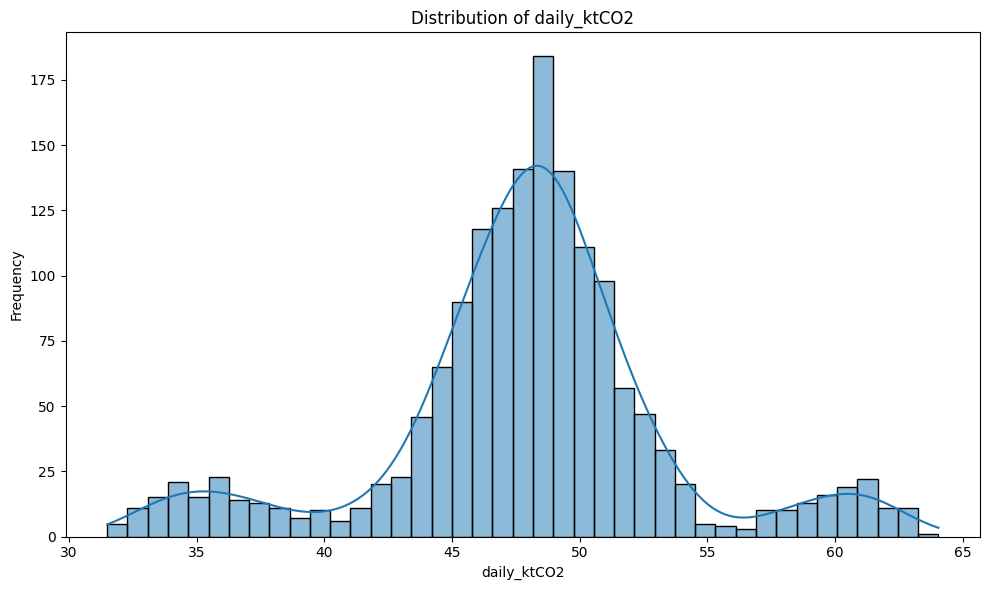

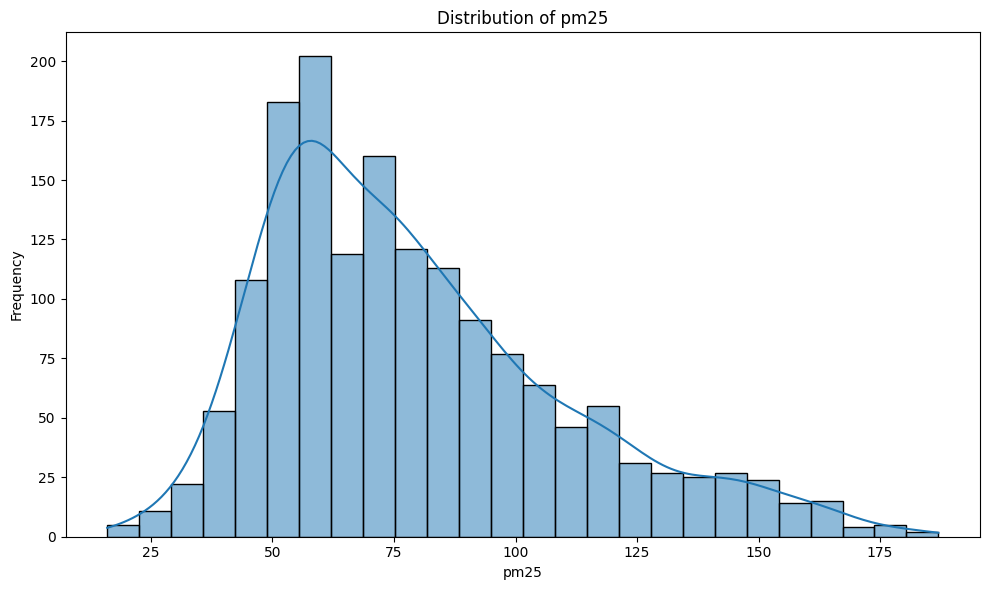

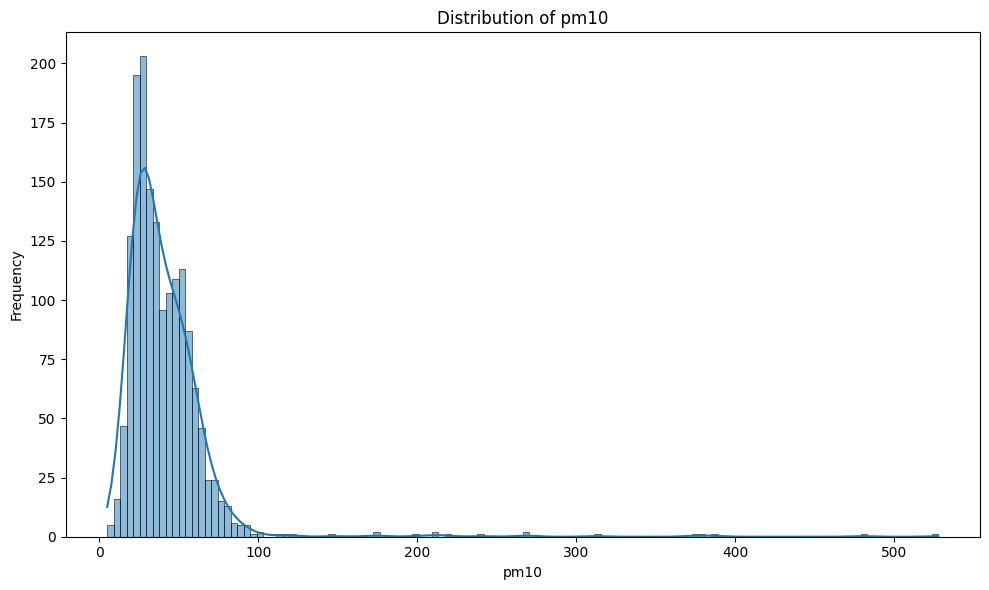

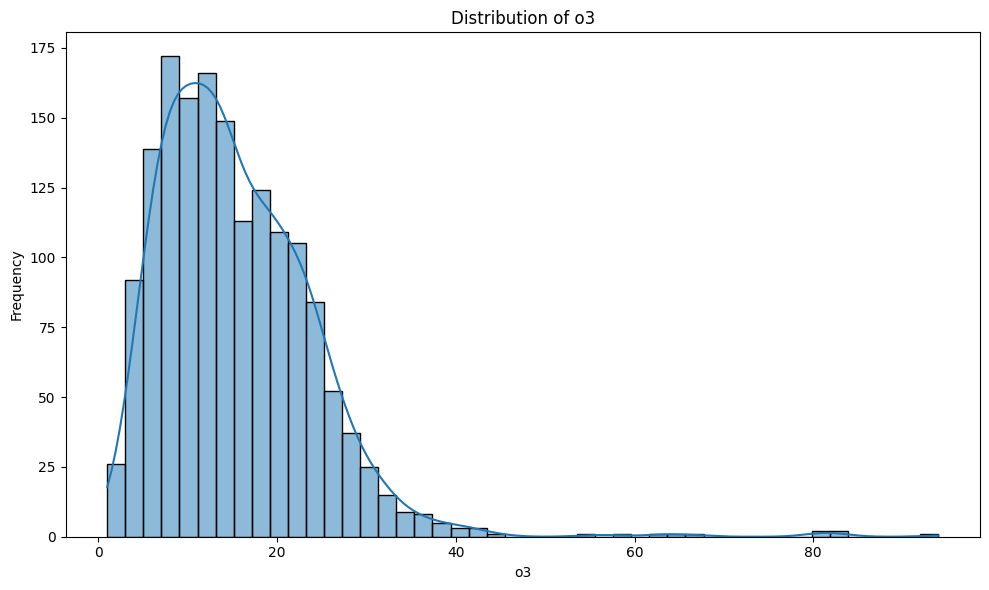

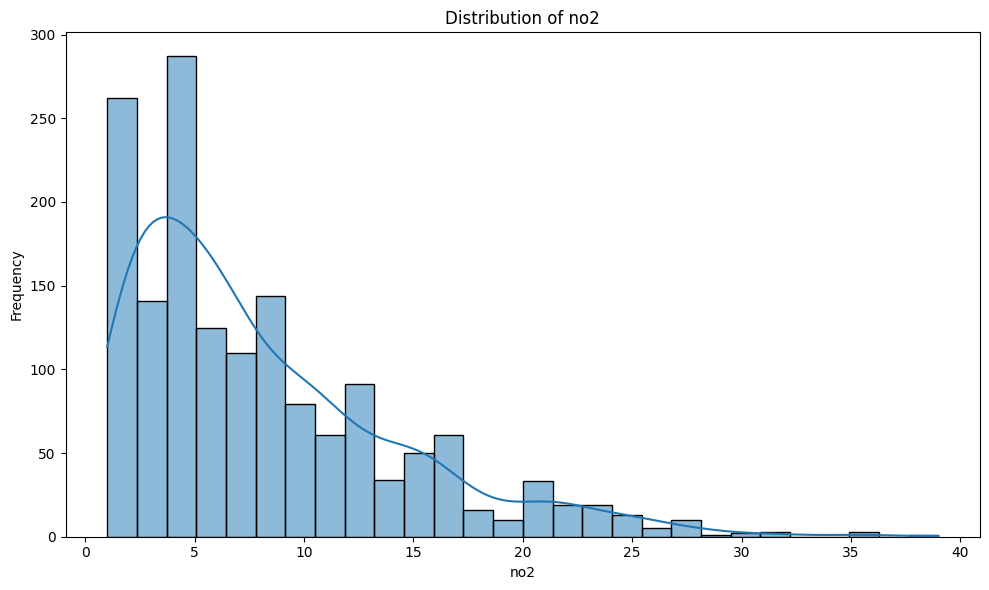

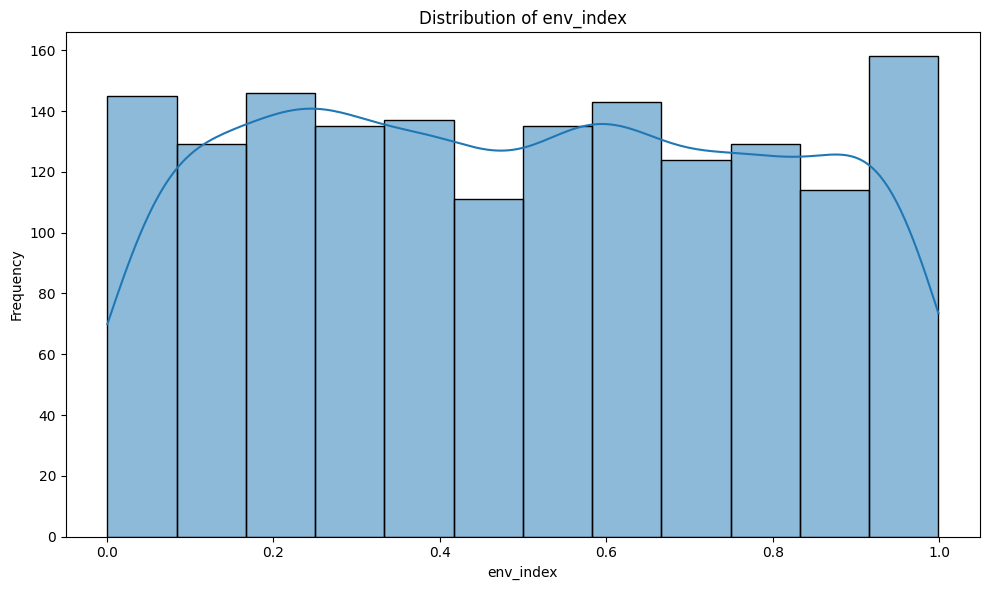

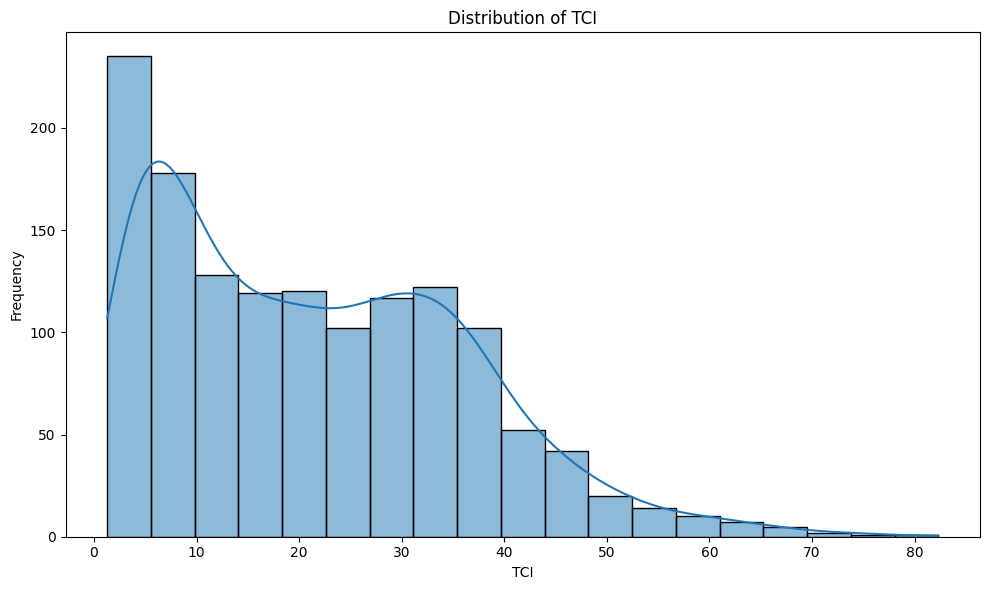

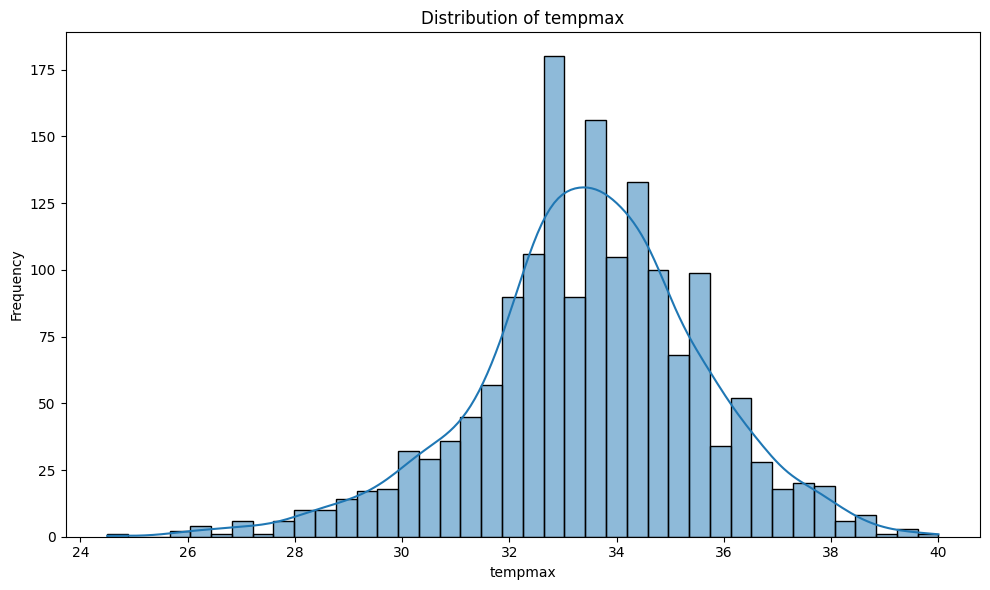

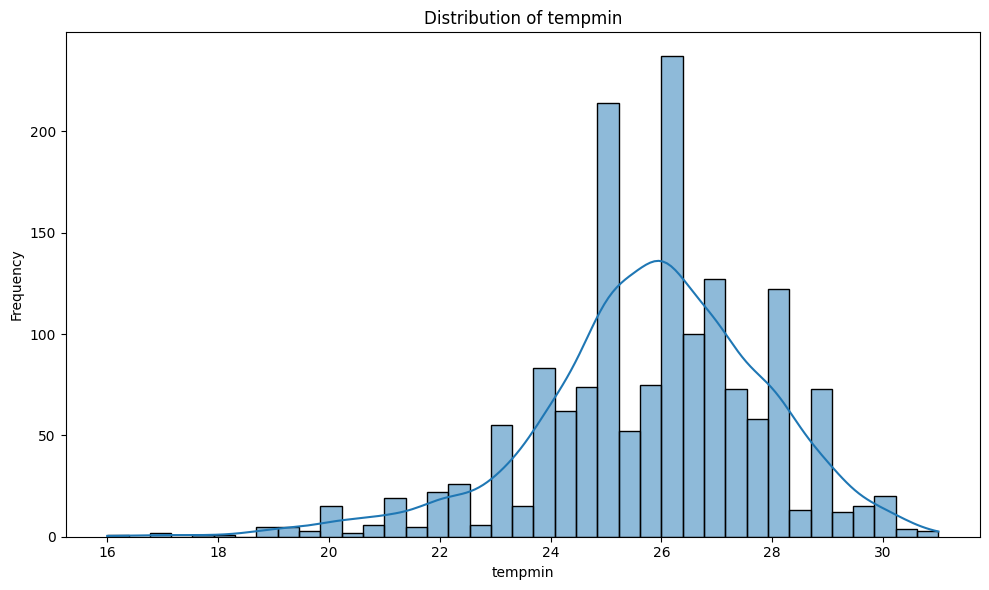

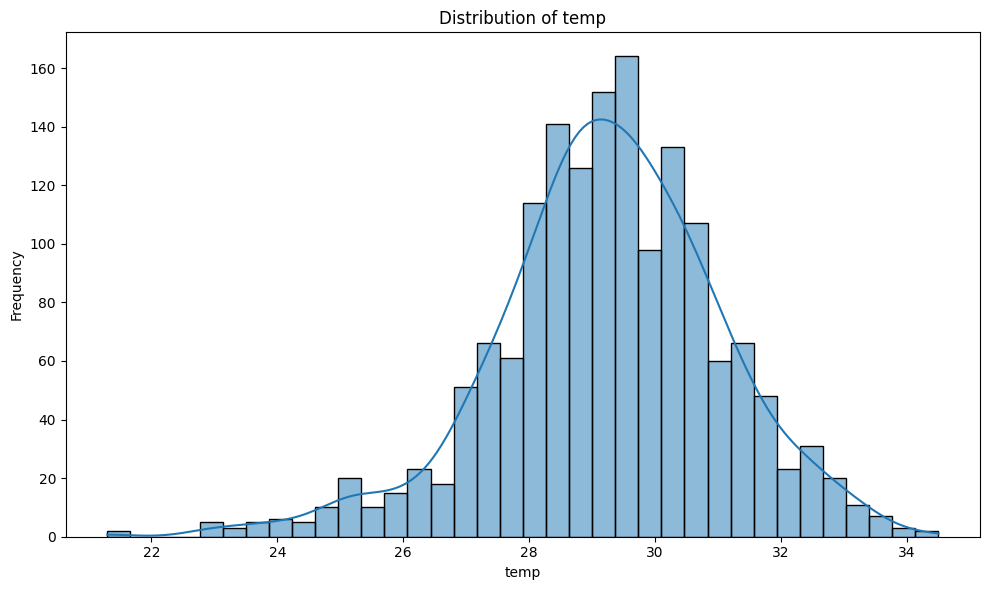

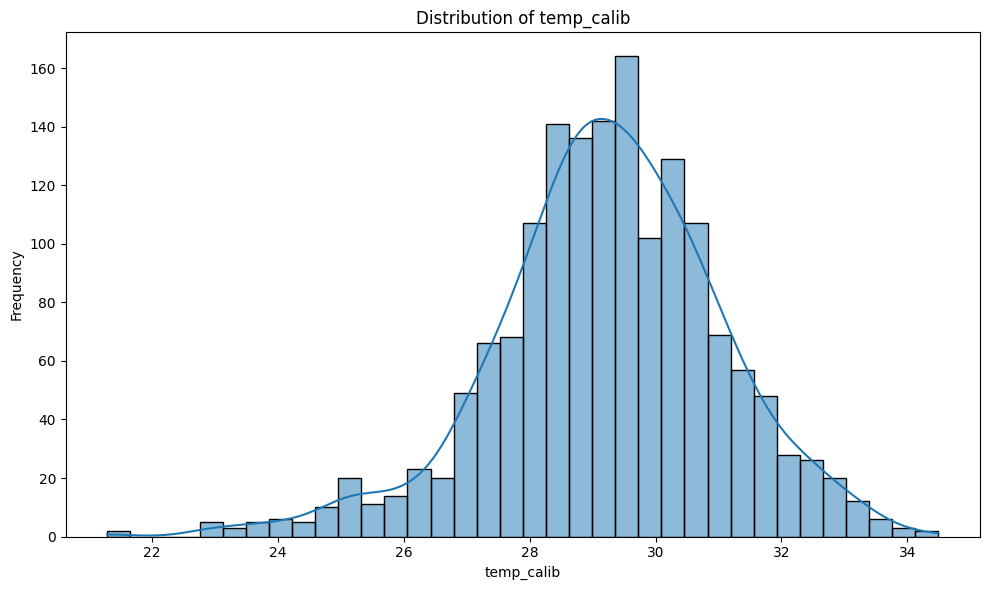

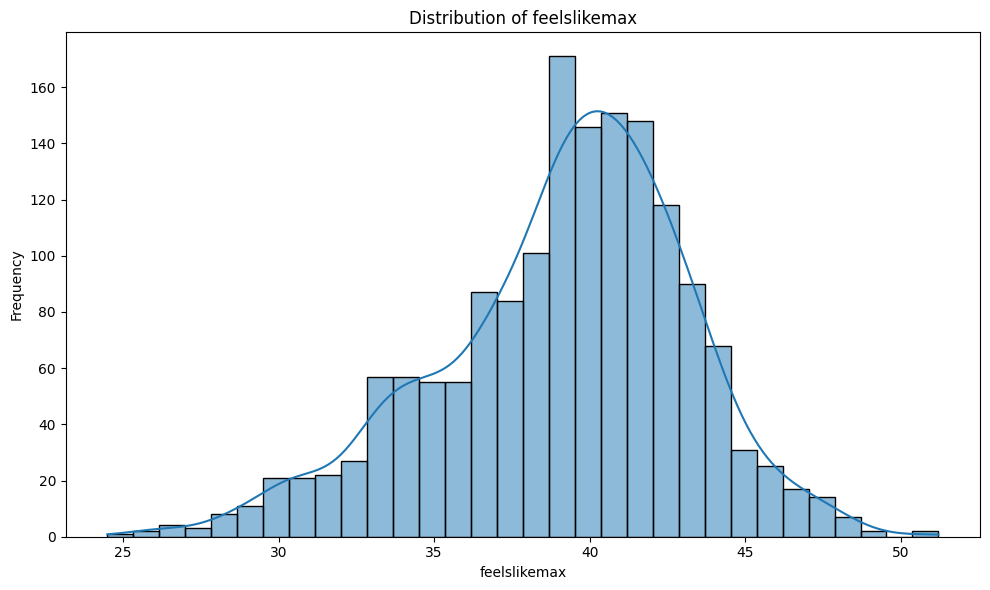

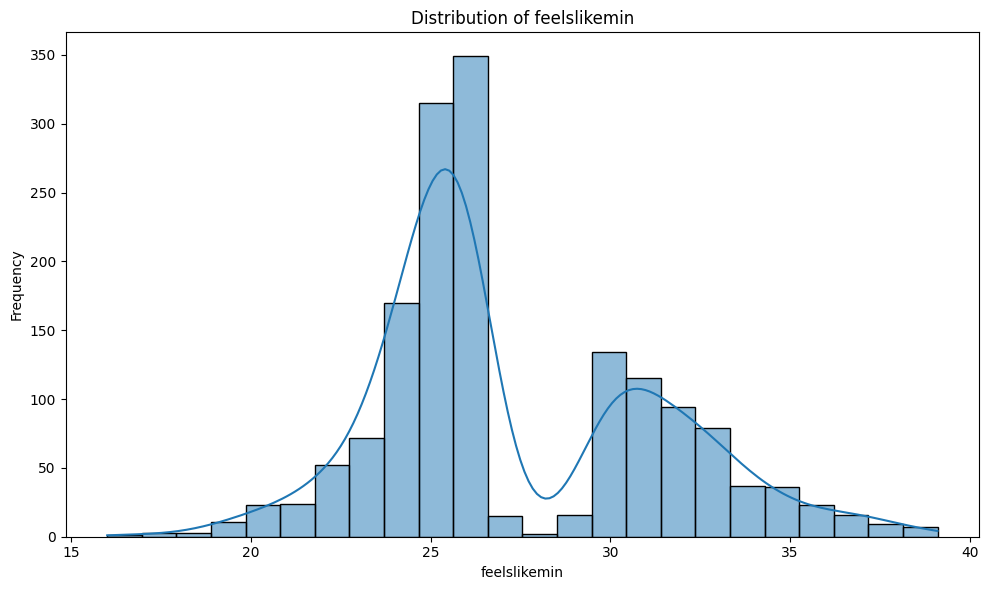

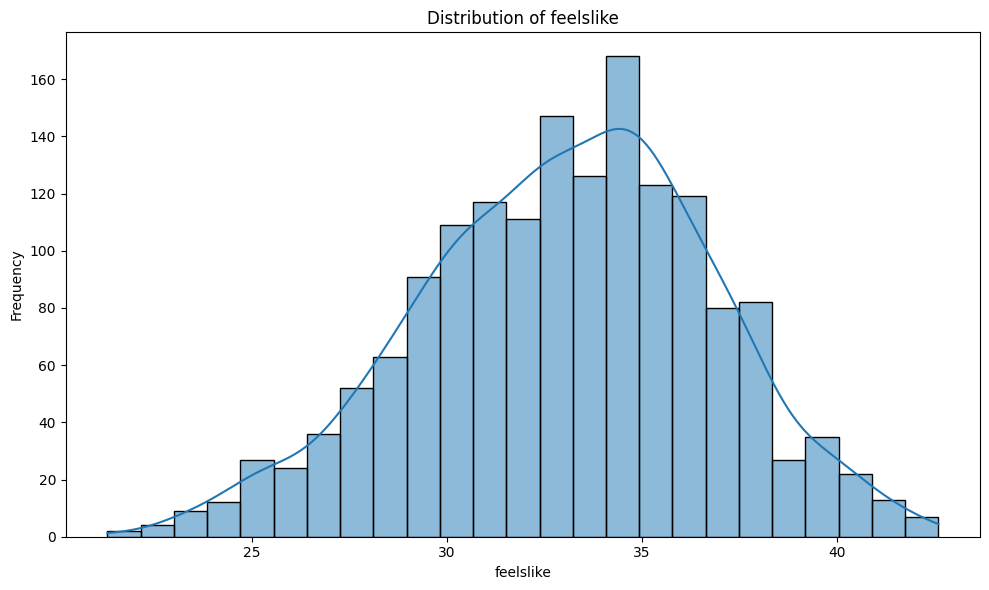

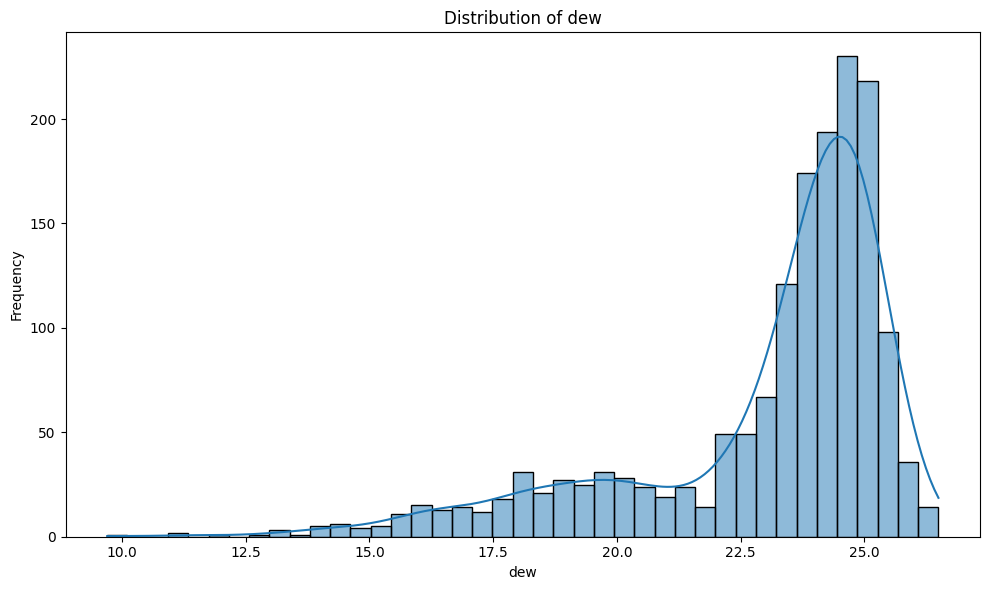

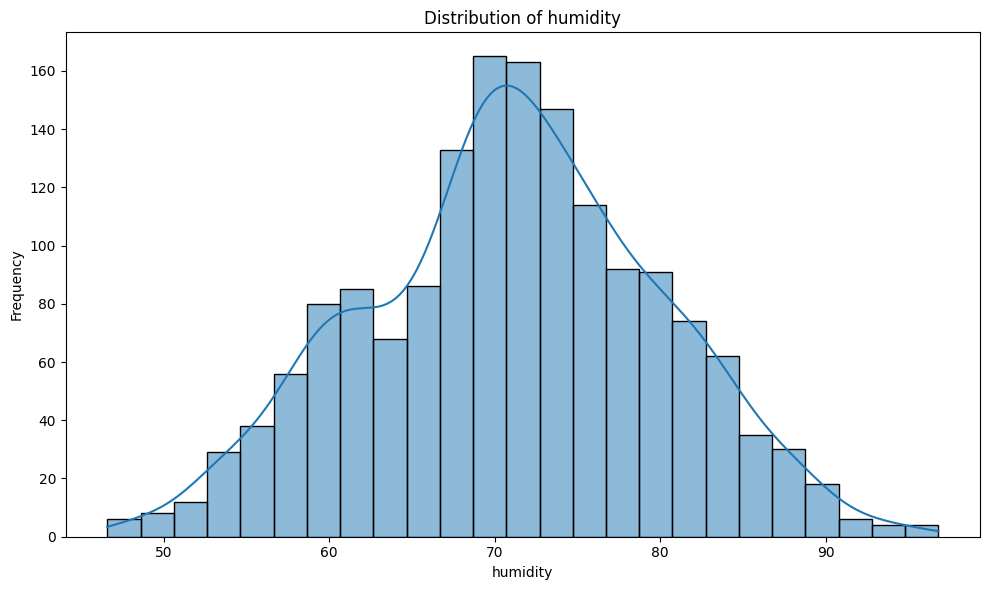

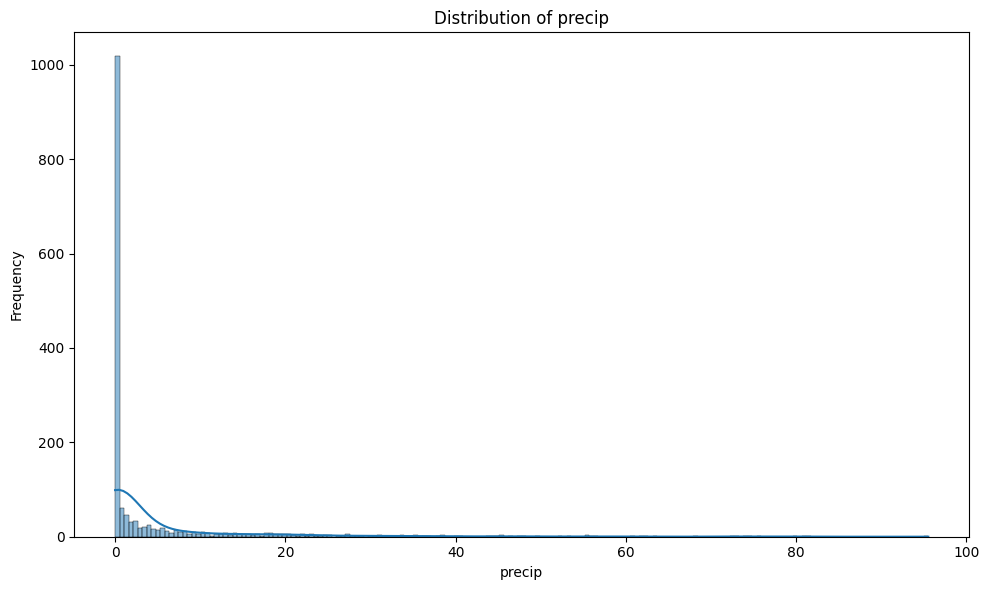

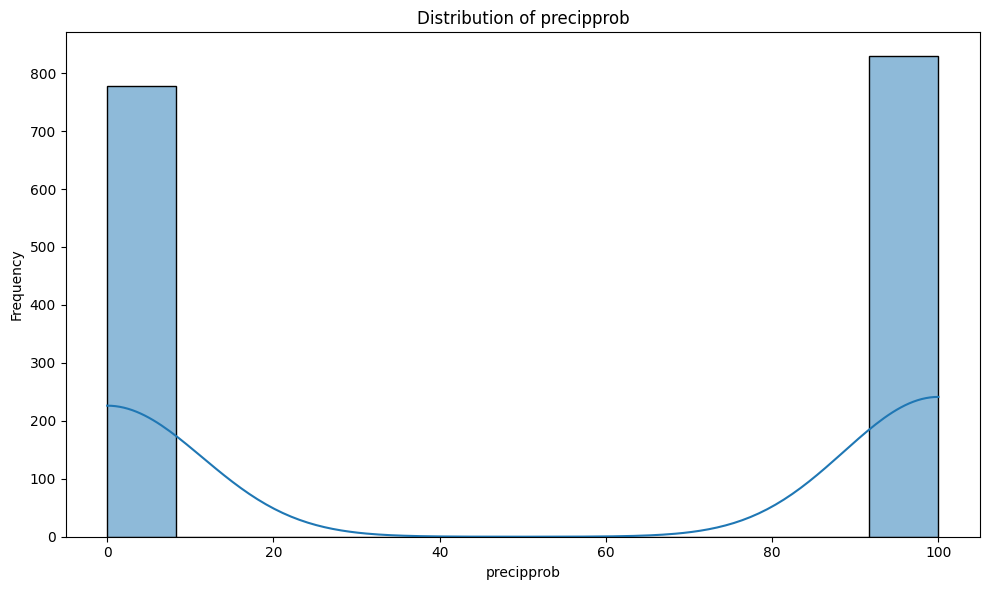

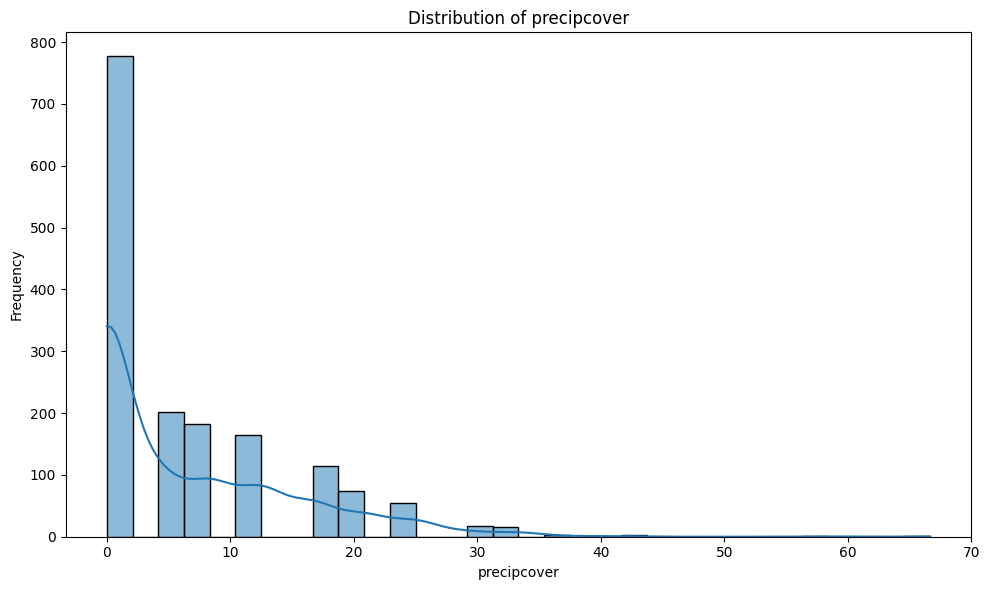

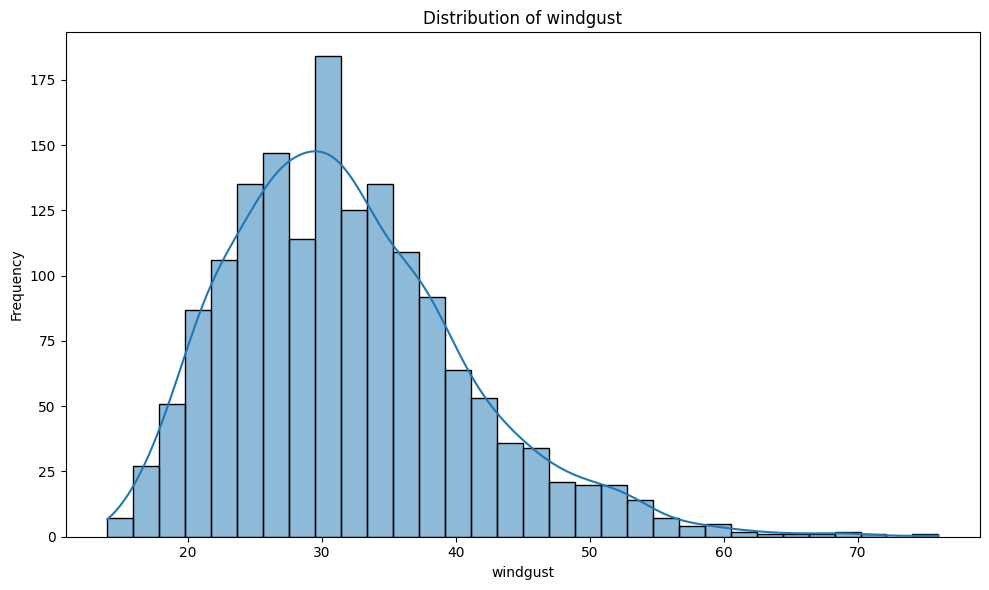

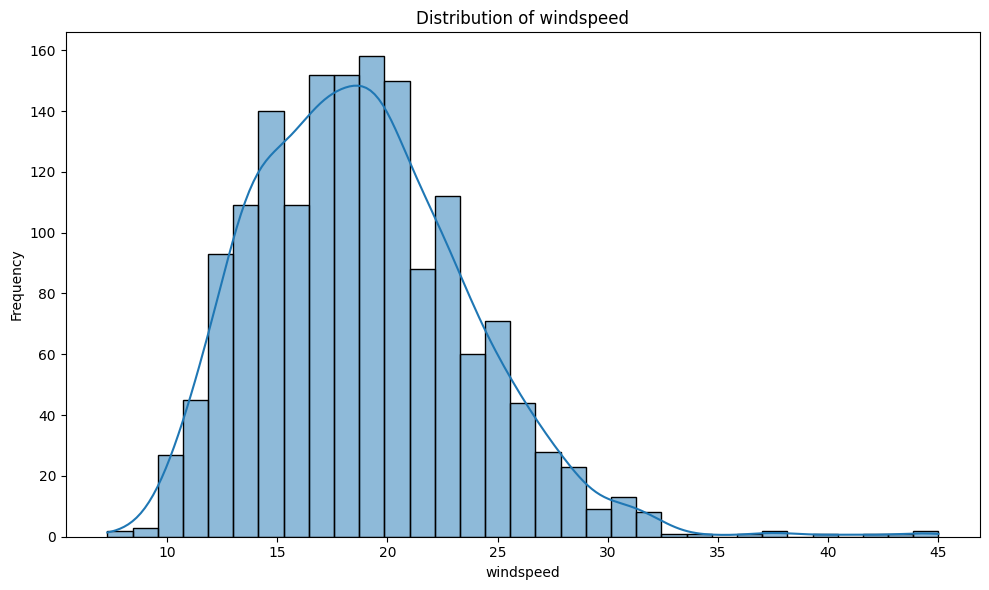

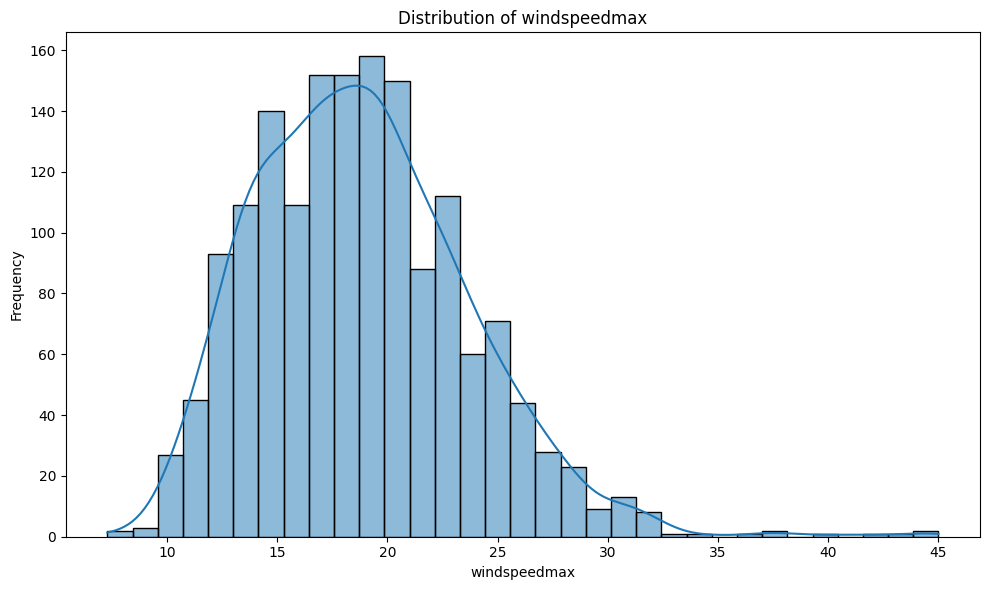

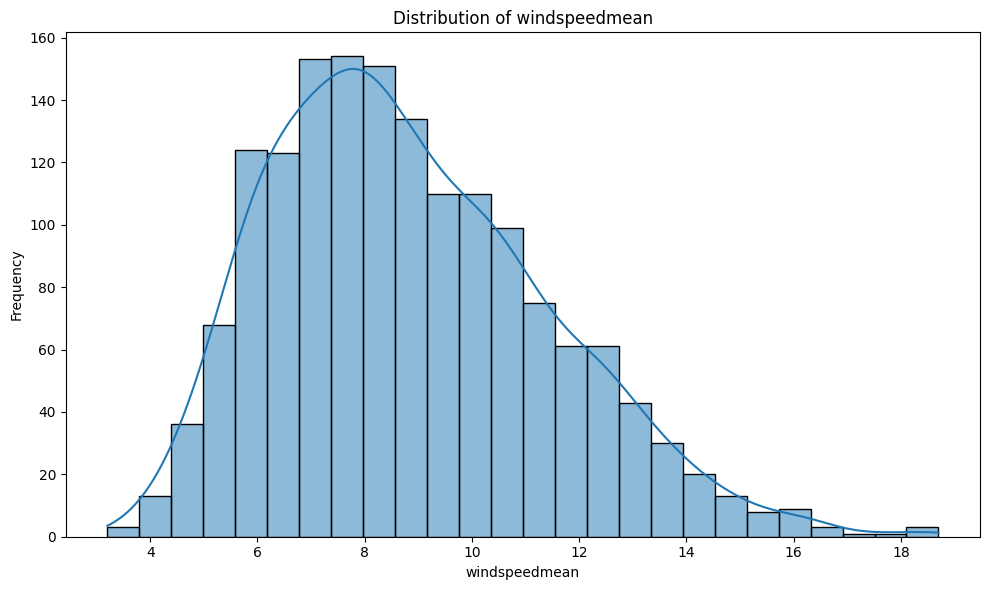

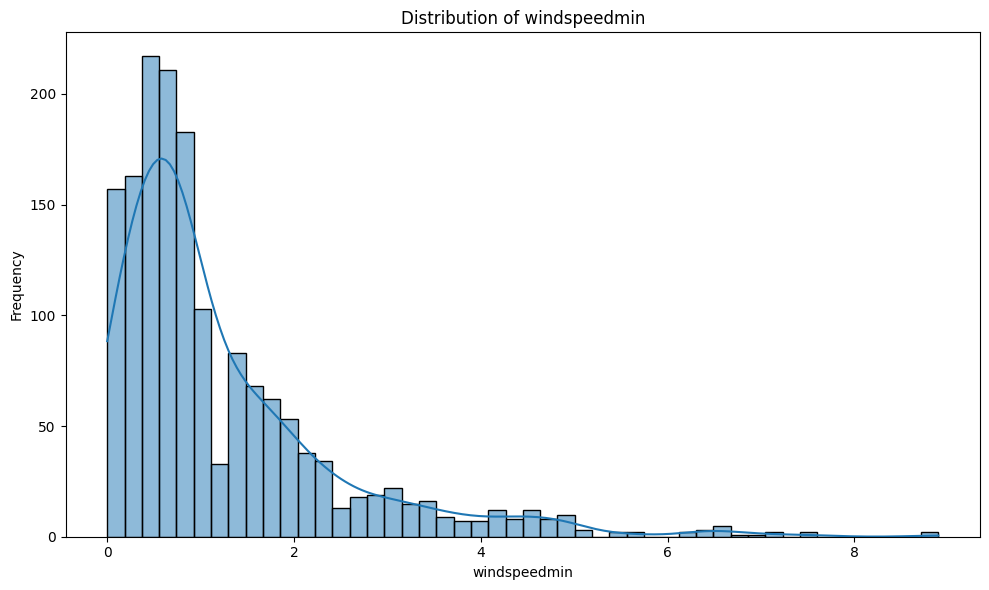

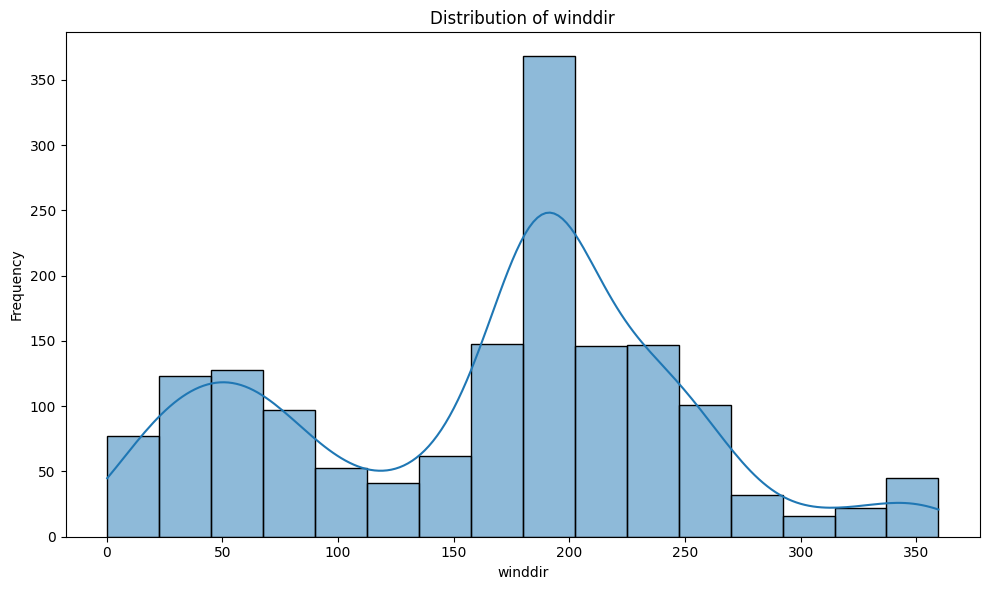

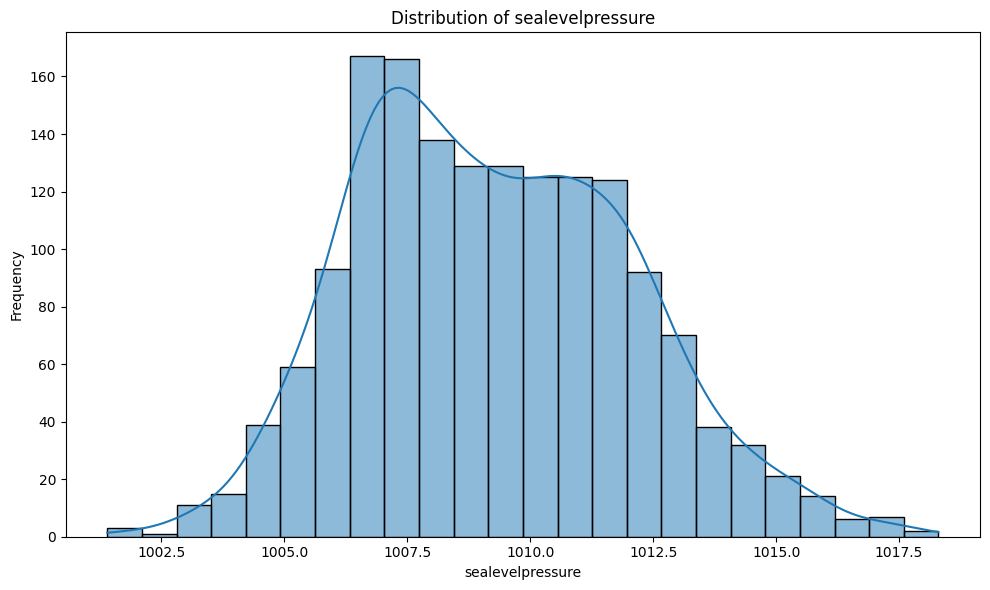

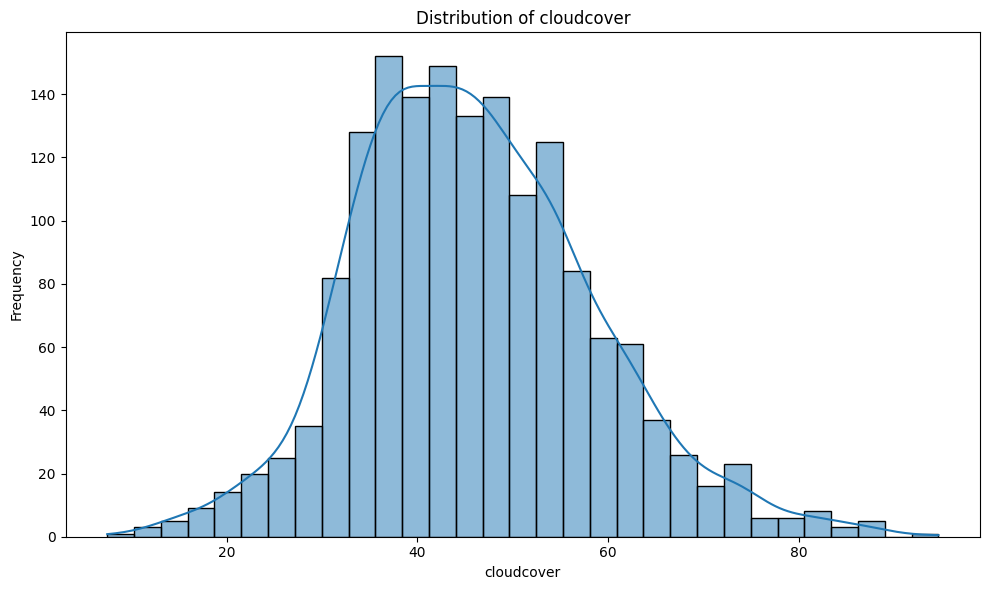

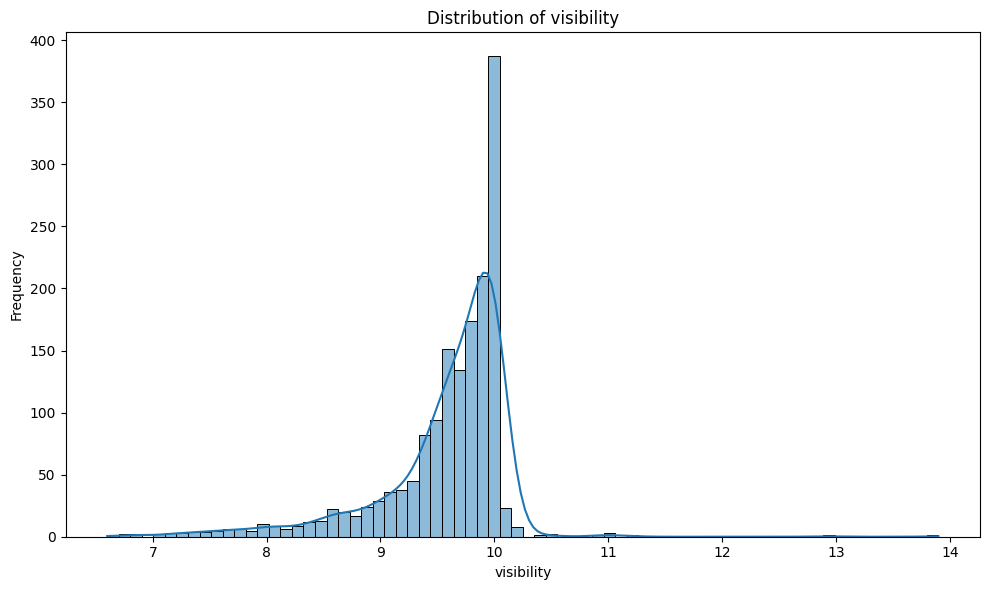

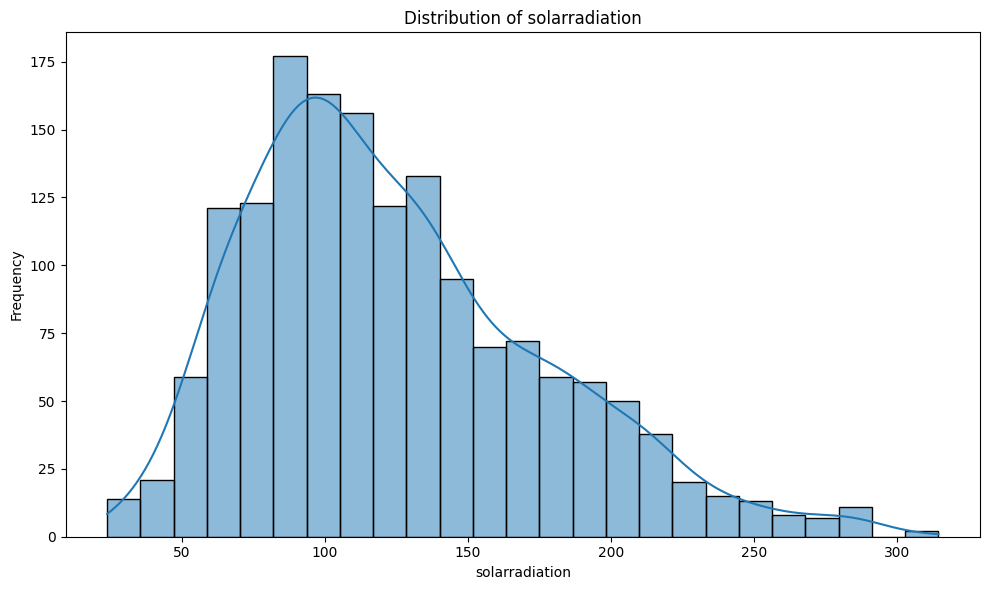

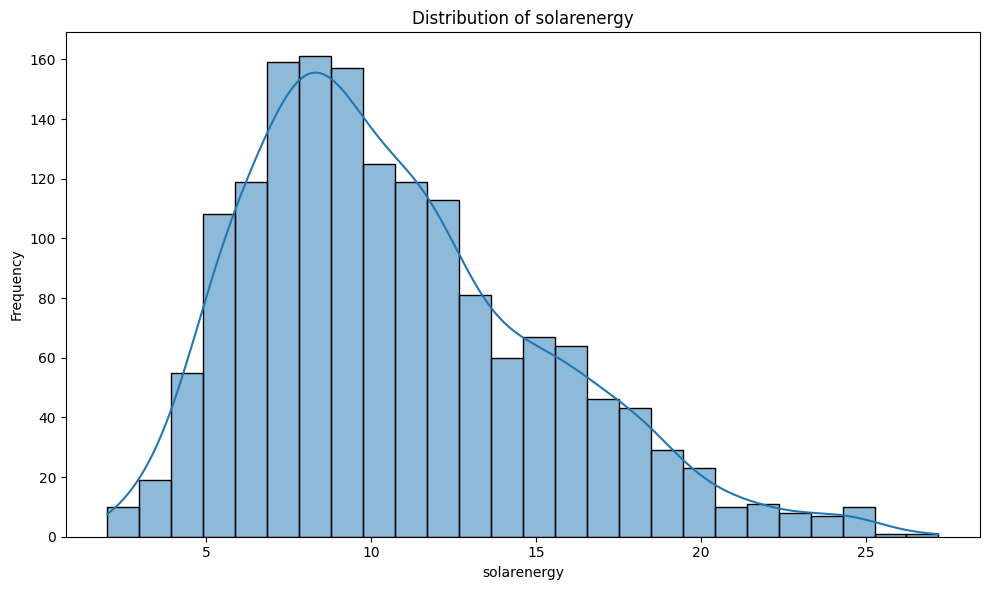

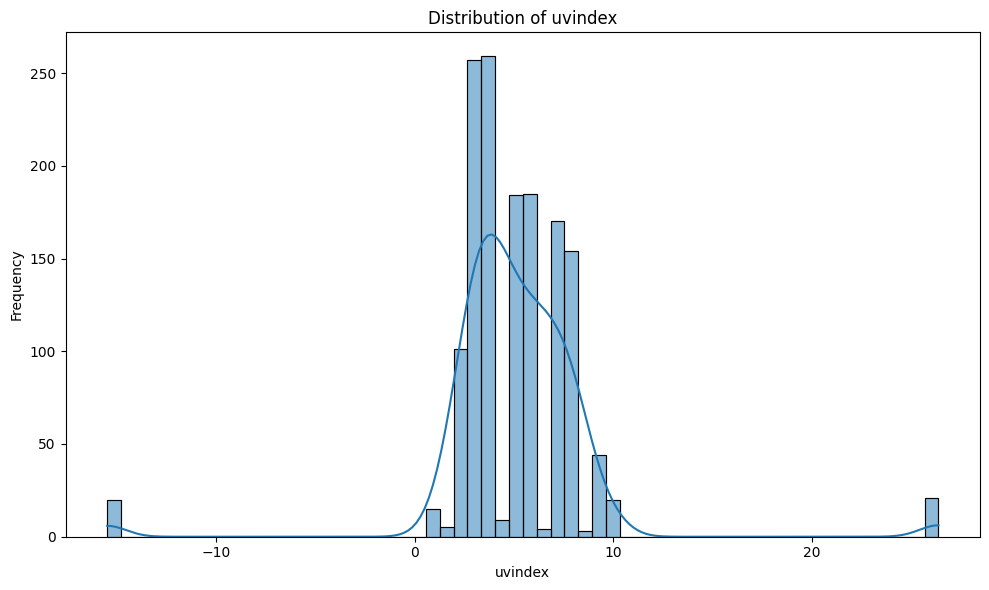

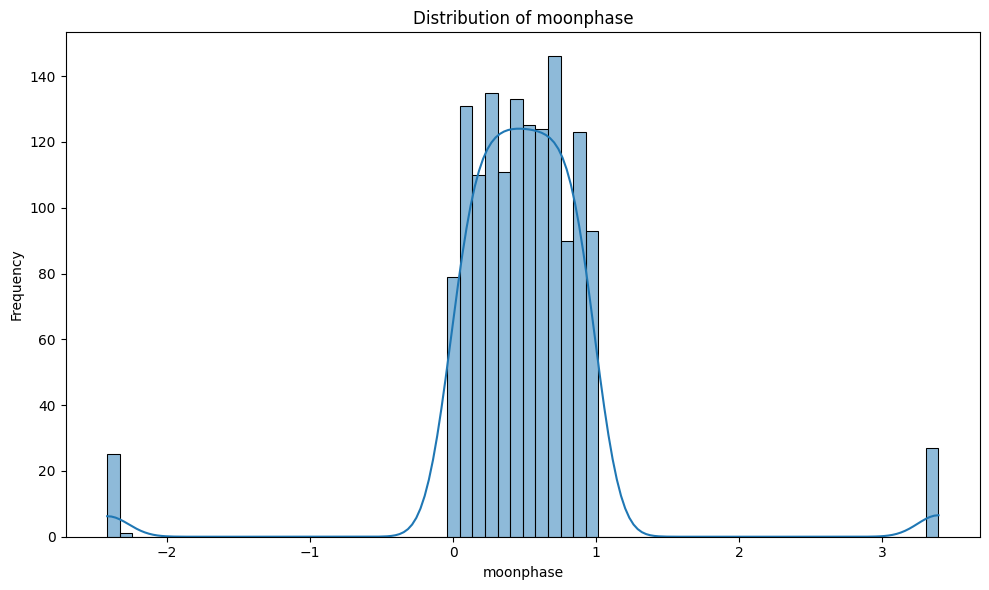


Count Plots of Categorical Features:


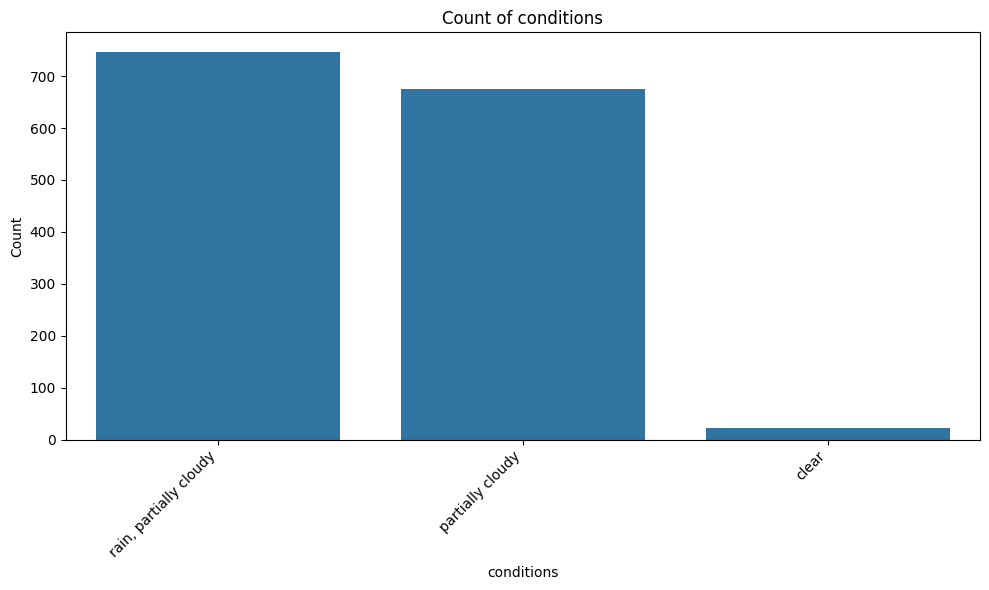

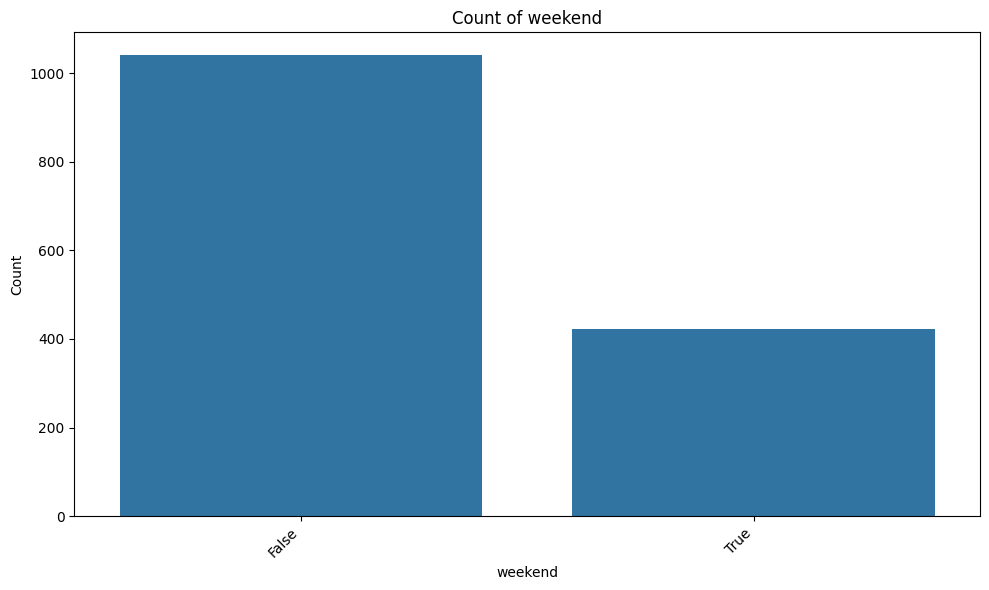

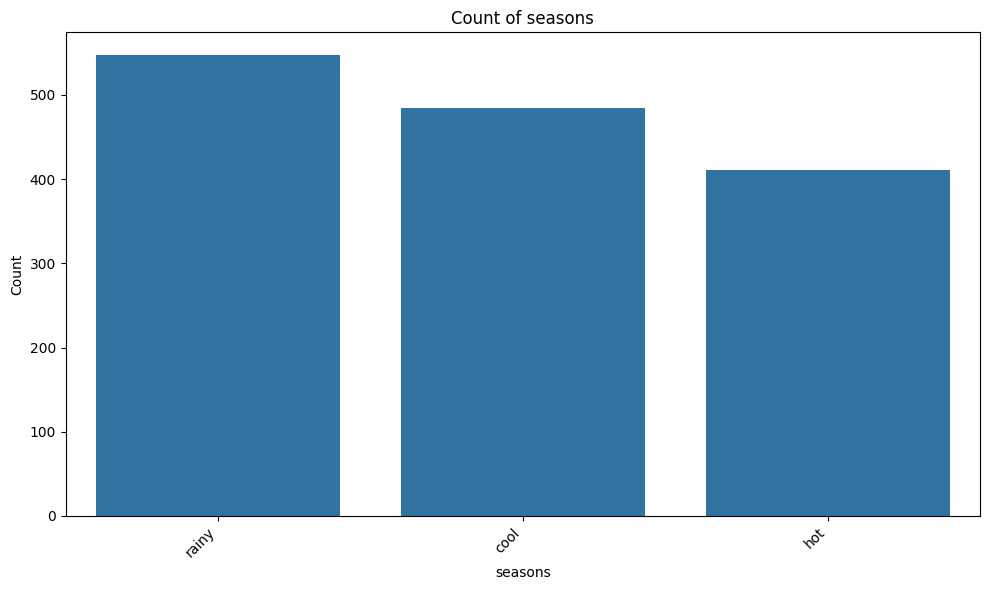

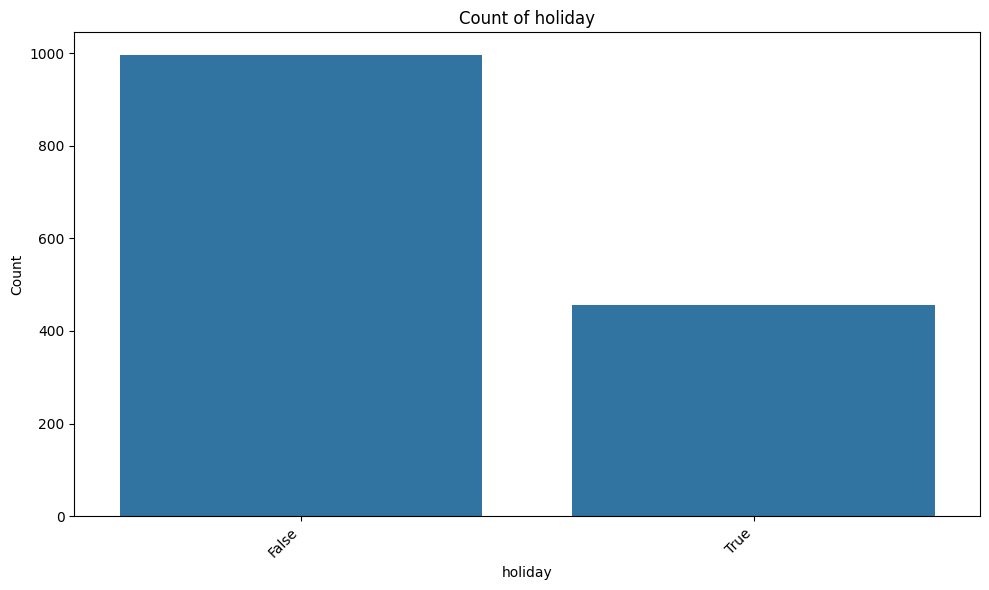

In [11]:
# Select numerical columns
numerical_cols = train.select_dtypes(include=np.number).columns.tolist()

# Remove 'obs_id' as it's an identifier, not a feature for distribution analysis
if 'obs_id' in numerical_cols:
    numerical_cols.remove('obs_id')

# Create histograms for each numerical column
print("Histograms of Numerical Features:")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=train, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Select categorical columns
# Exclude 'date' as it's datetime and 'source' as it's a marker
categorical_cols = train.select_dtypes(include='object').columns.tolist()
if 'date' in categorical_cols:
    categorical_cols.remove('date')
if 'source' in categorical_cols:
    categorical_cols.remove('source')

# Create count plots for each categorical column
print("\nCount Plots of Categorical Features:")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=train, x=col, order=train[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Bivariate analysis


**Reasoning**:
Generate scatter plots for numerical features against the target variable, box plots for categorical features against the target, calculate the correlation matrix, and visualize it with a heatmap to explore feature relationships with `daily_ktCO2`.



Scatter plots of Numerical Features vs daily_ktCO2:


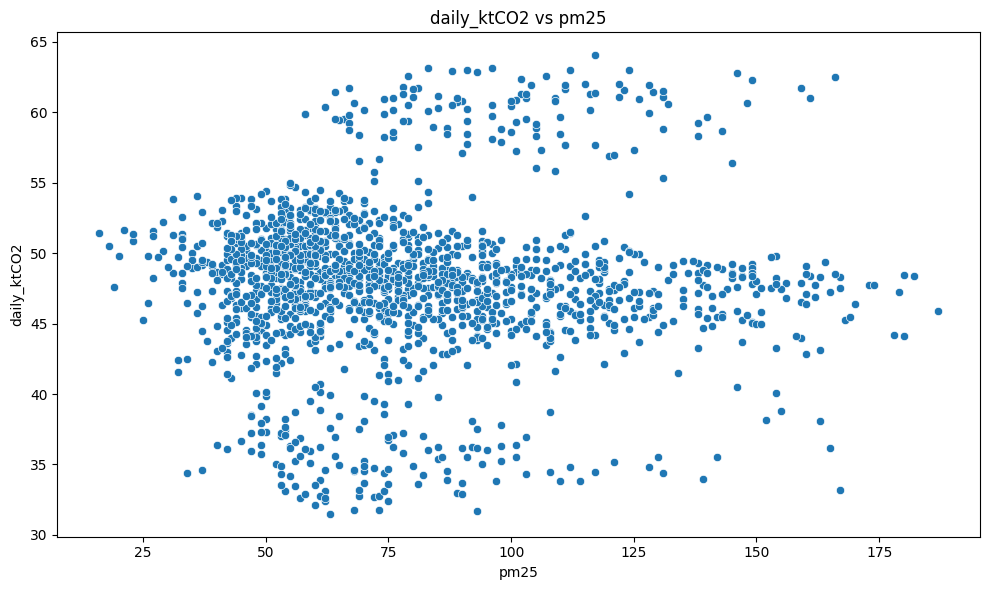

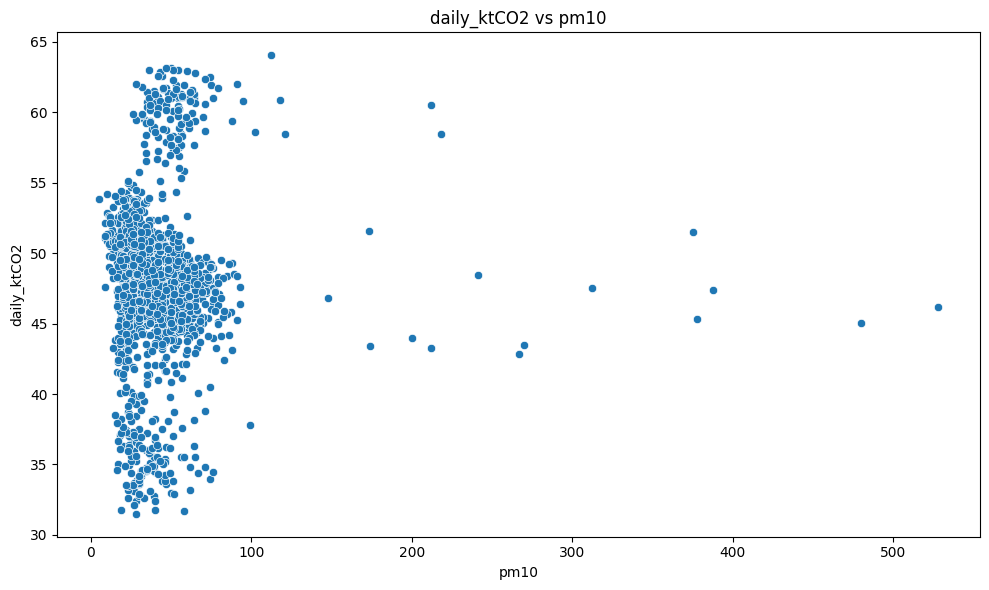

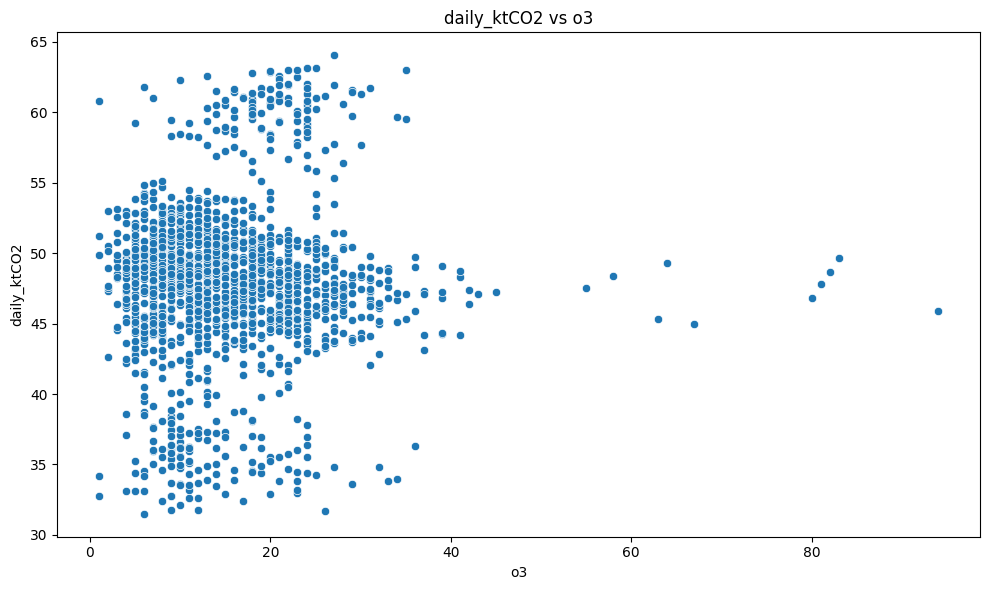

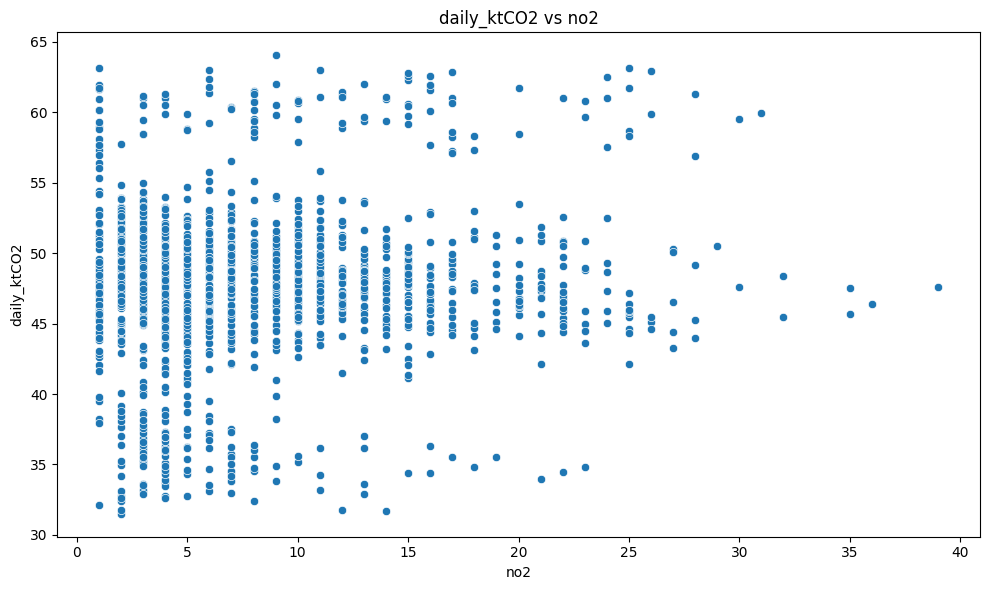

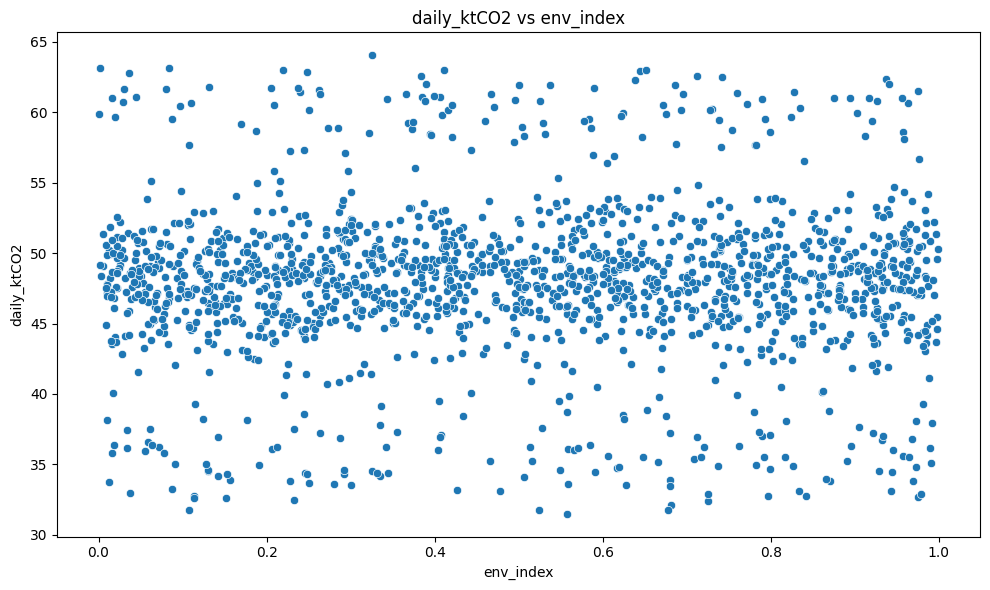

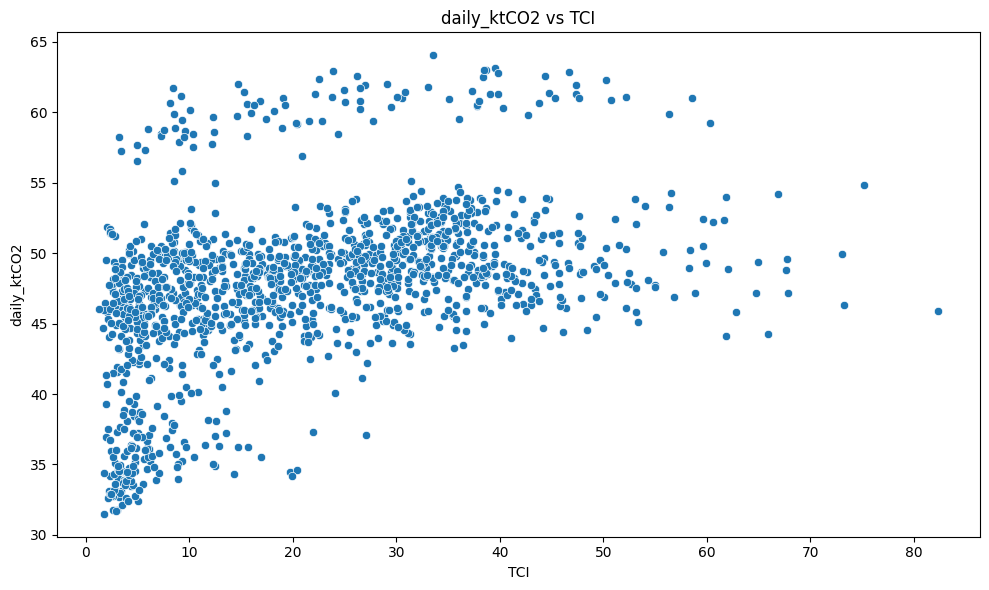

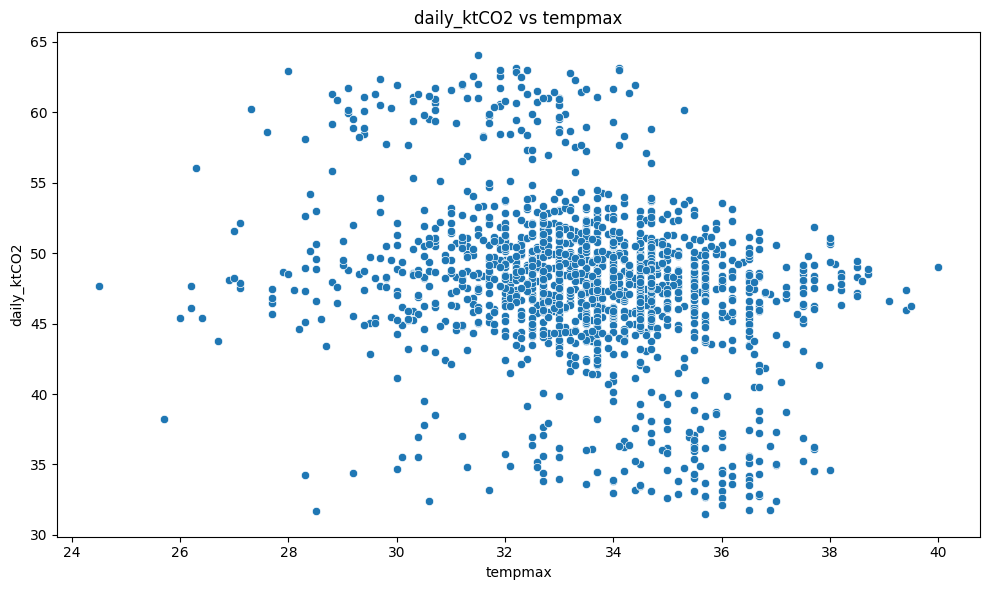

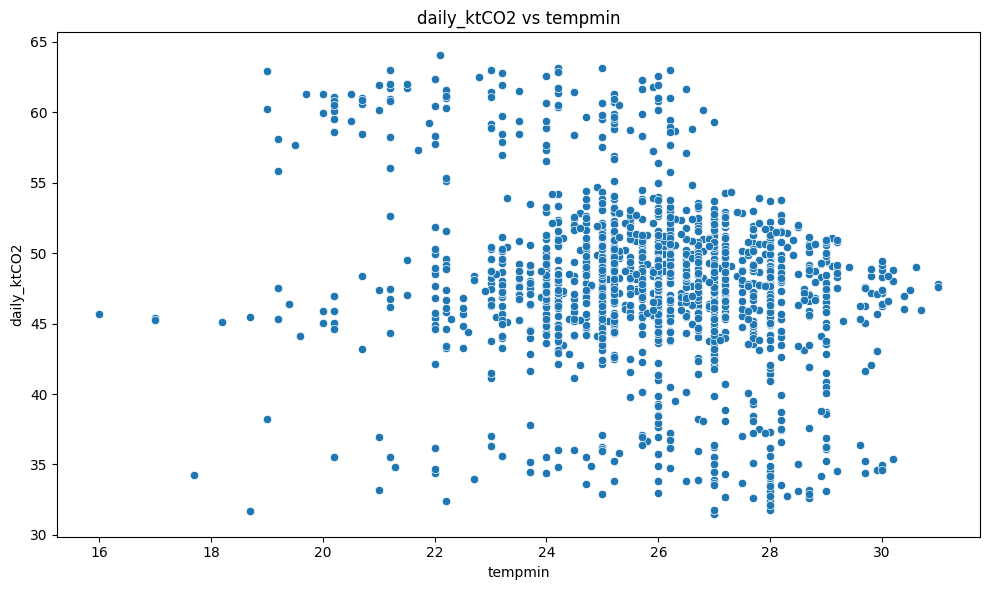

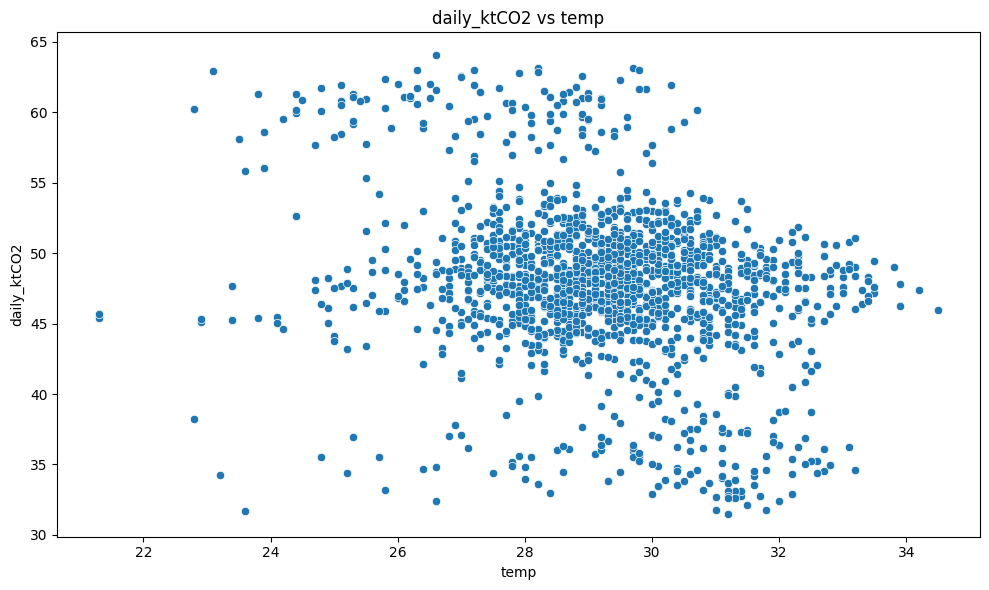

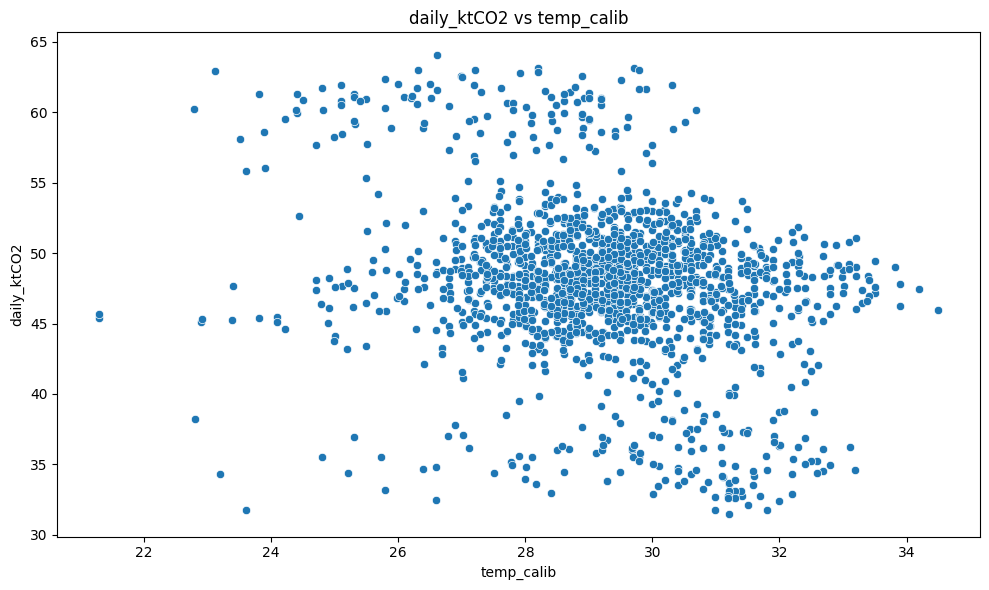

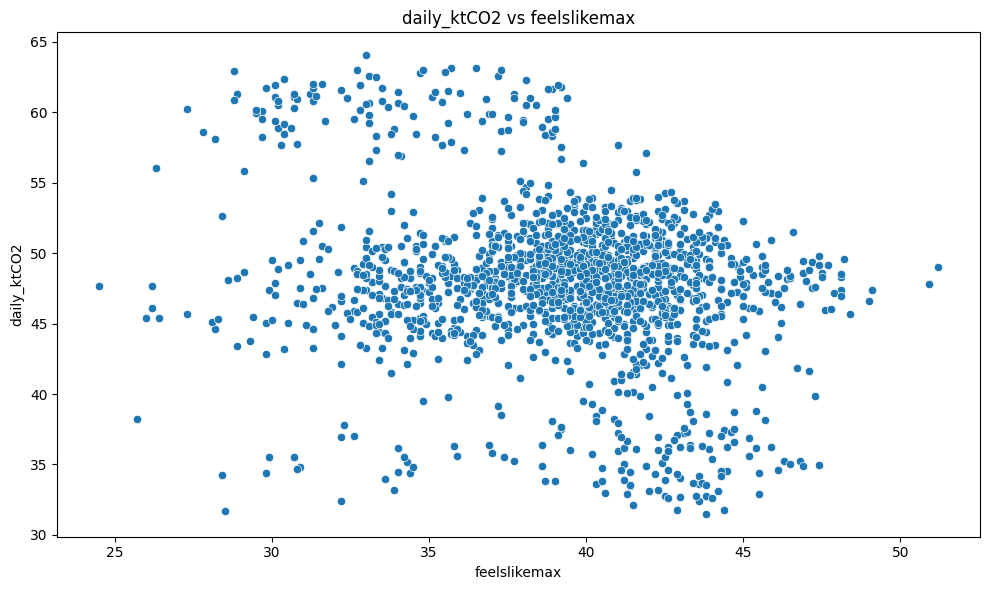

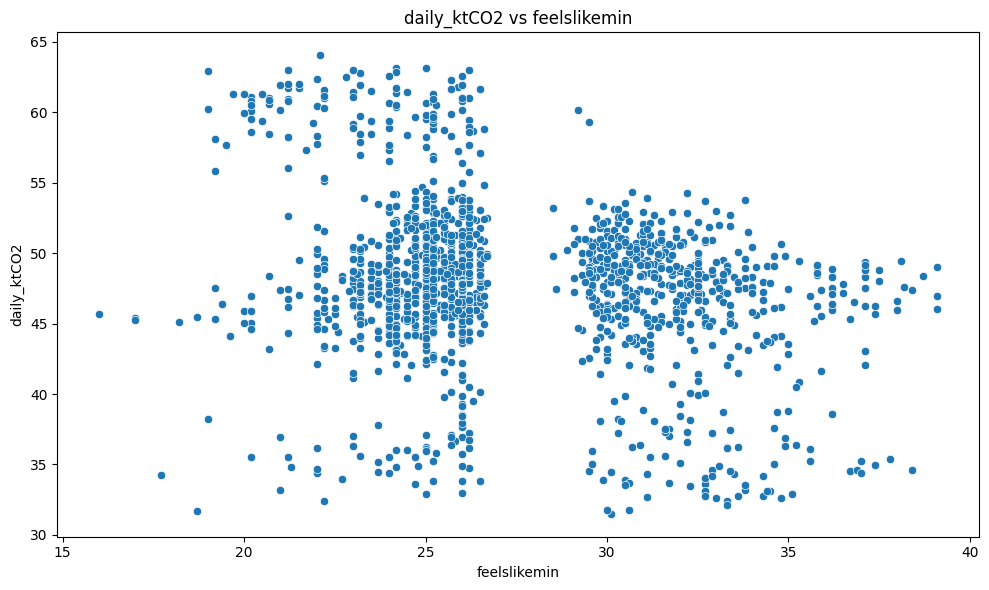

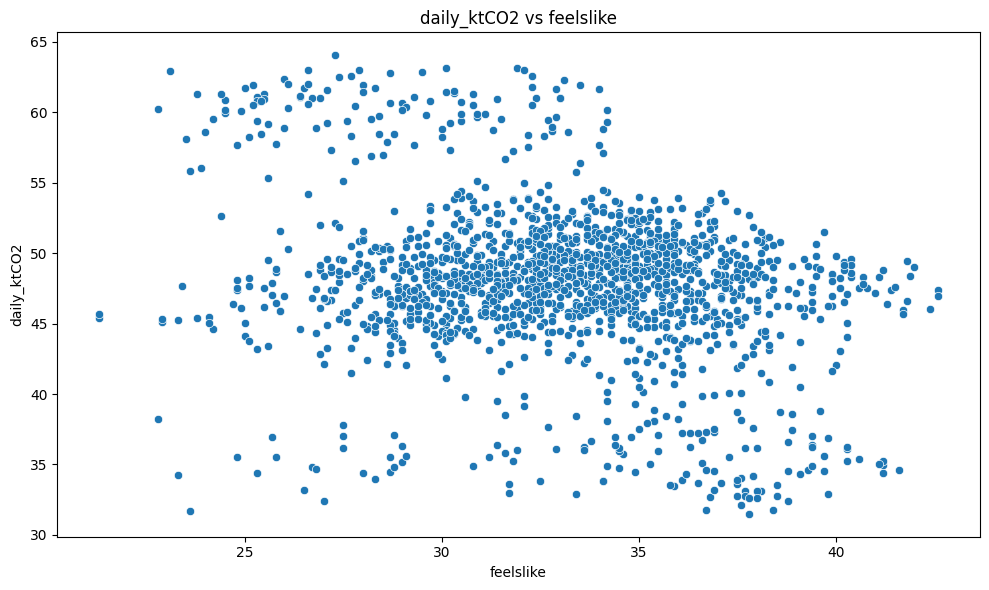

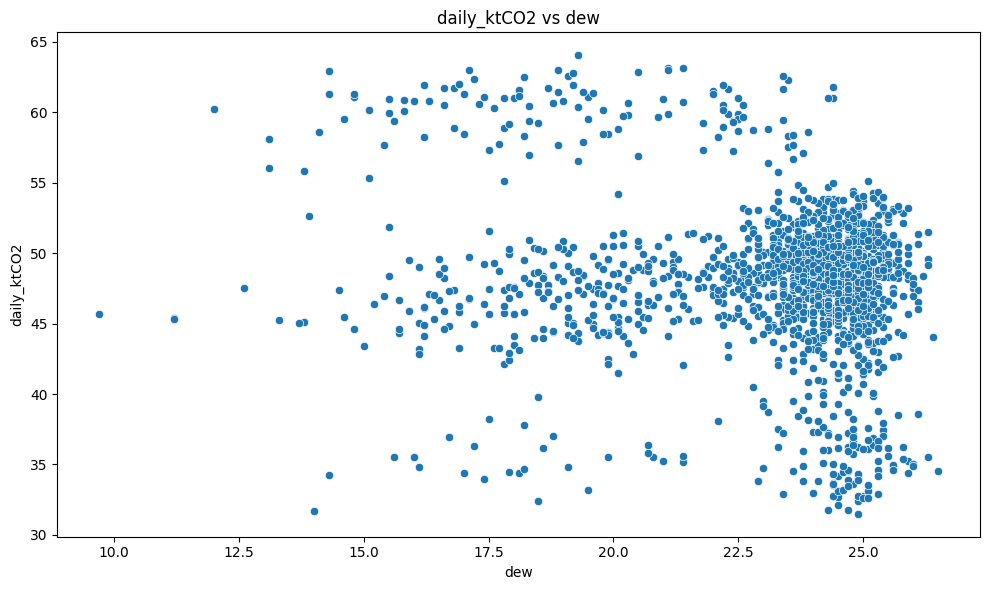

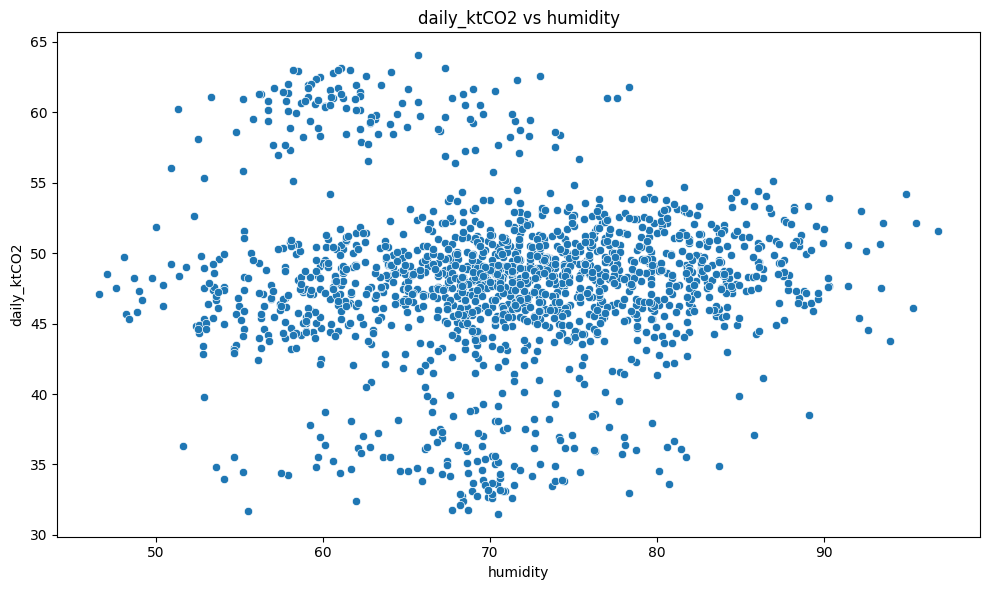

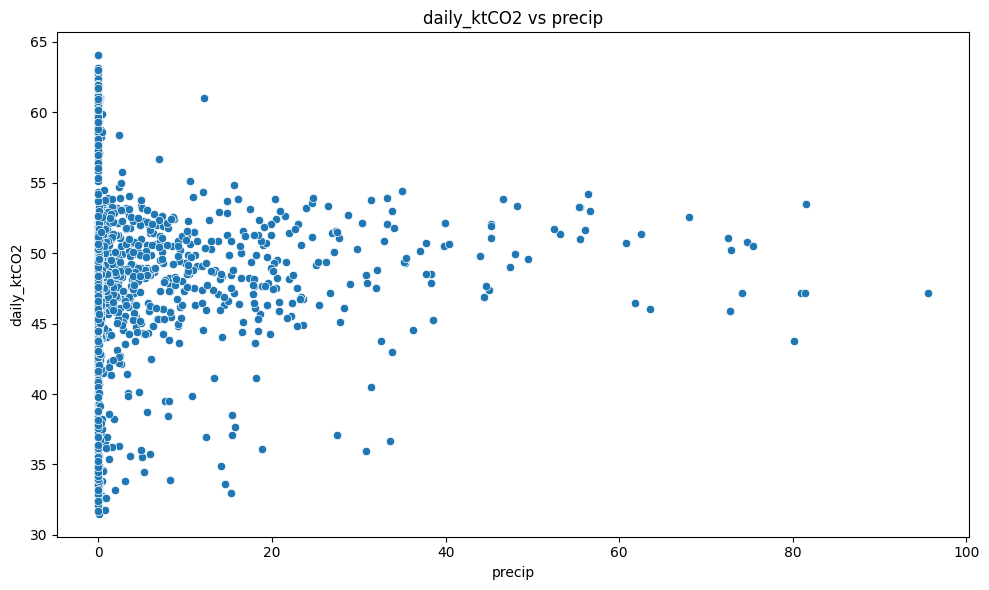

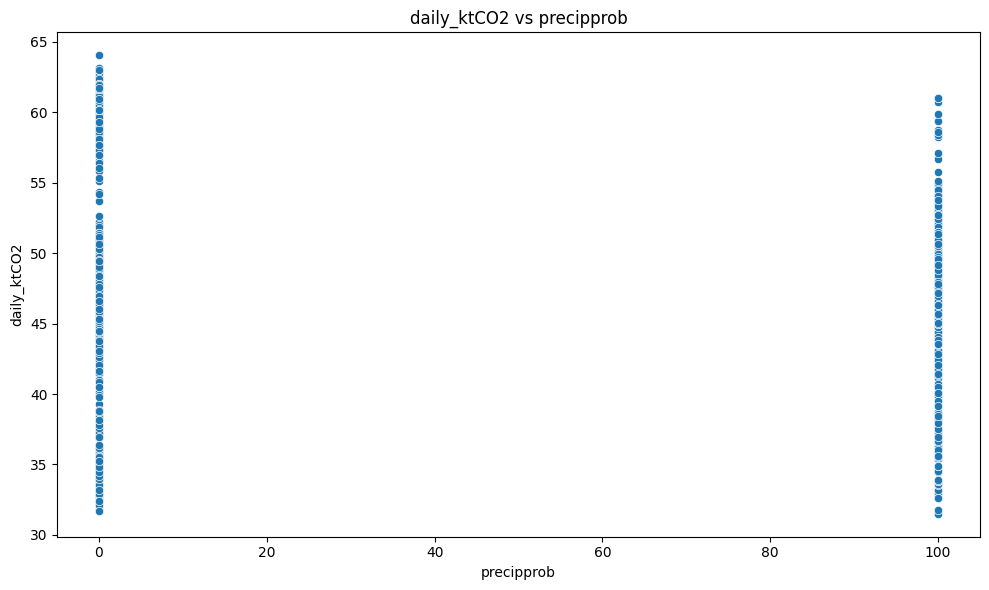

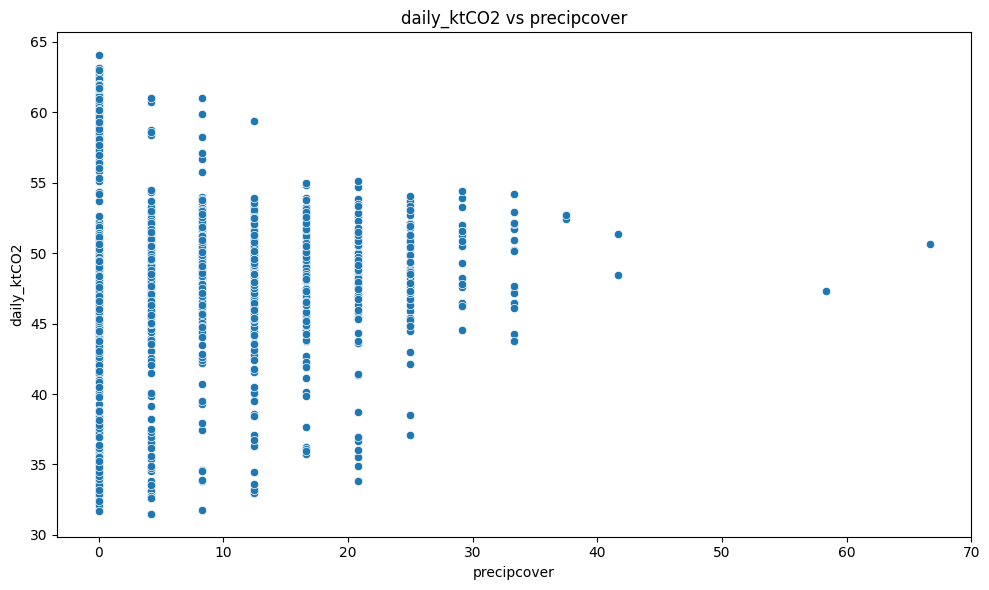

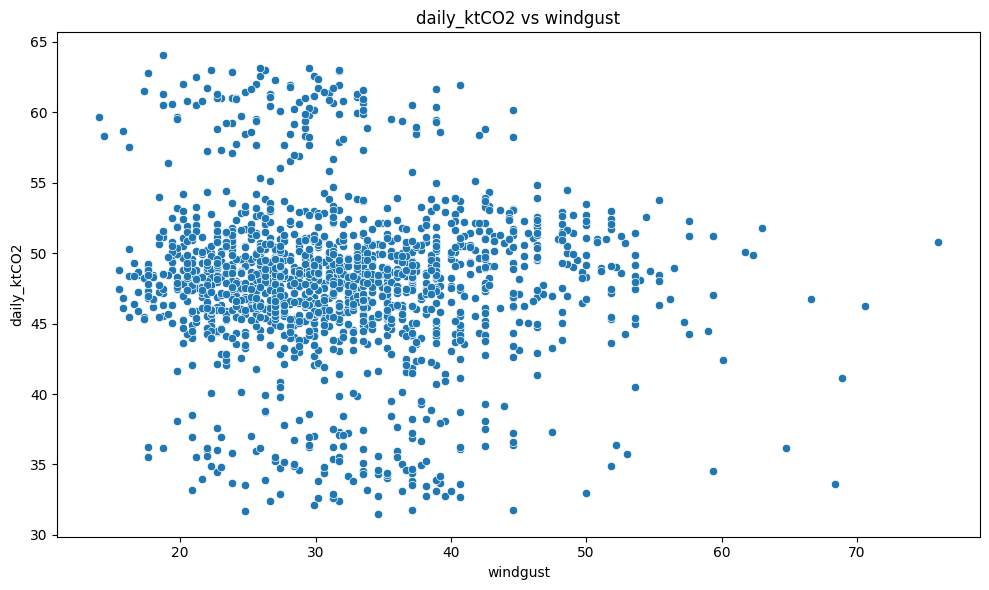

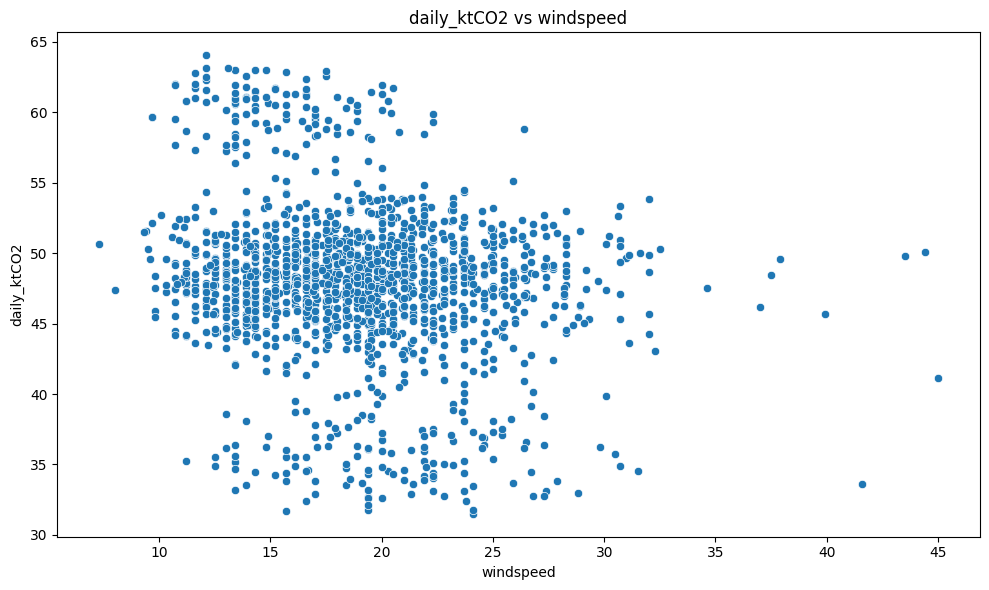

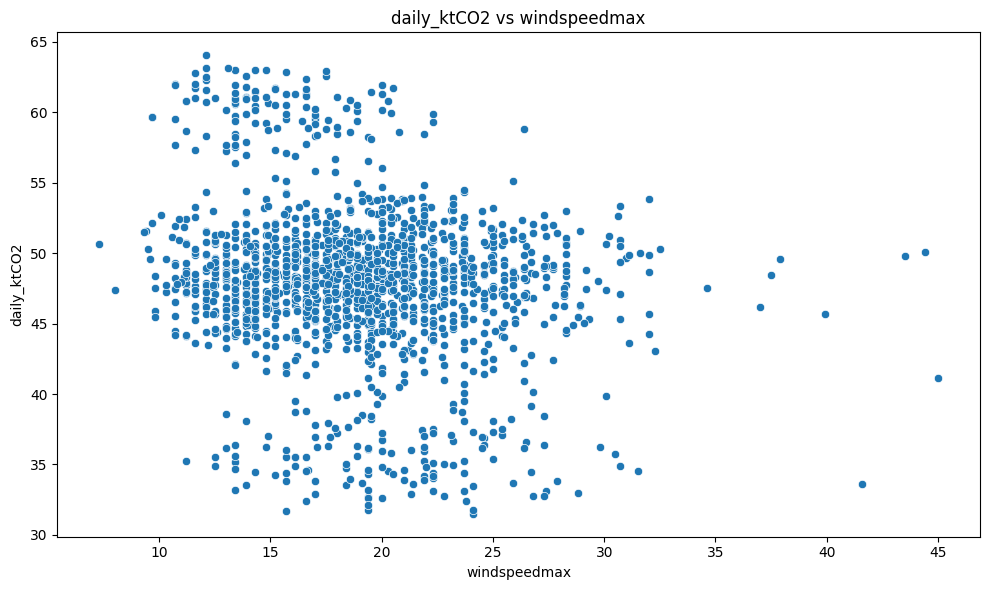

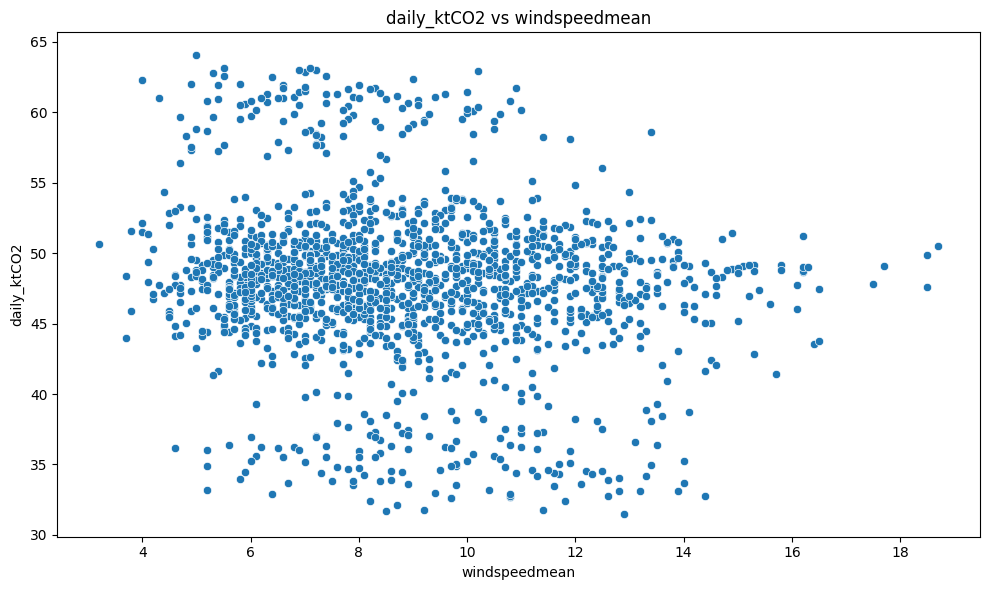

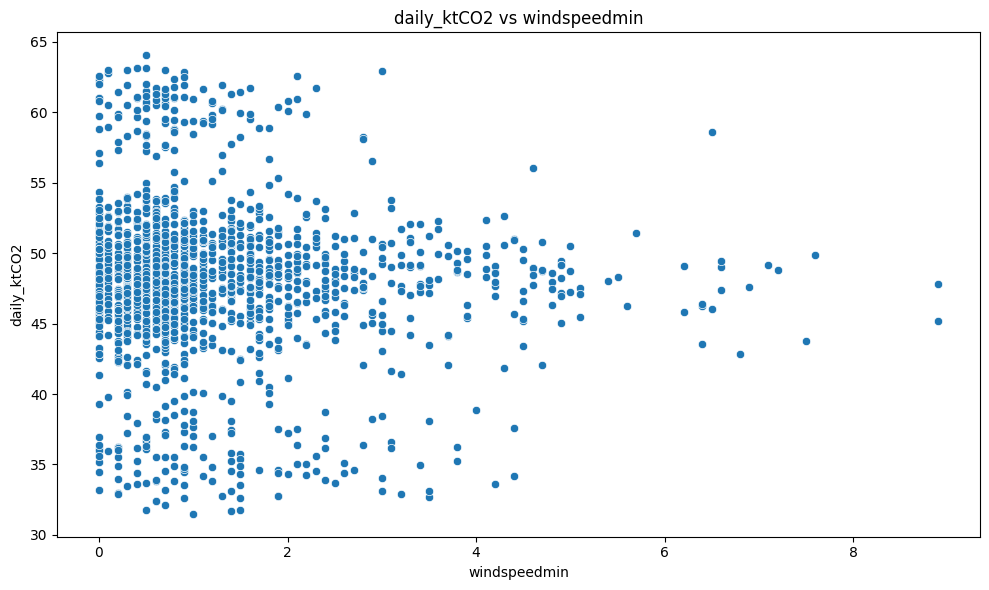

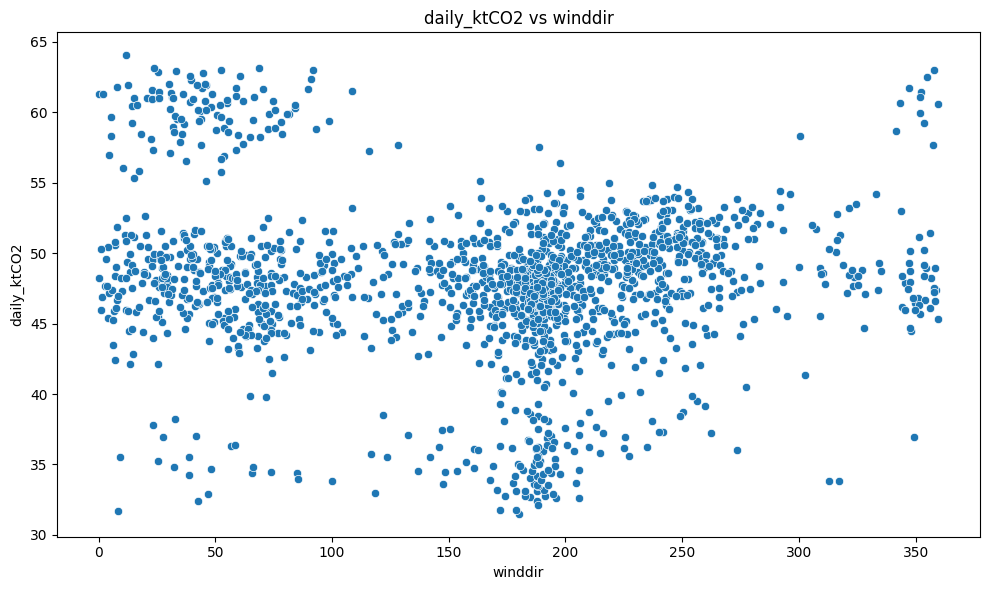

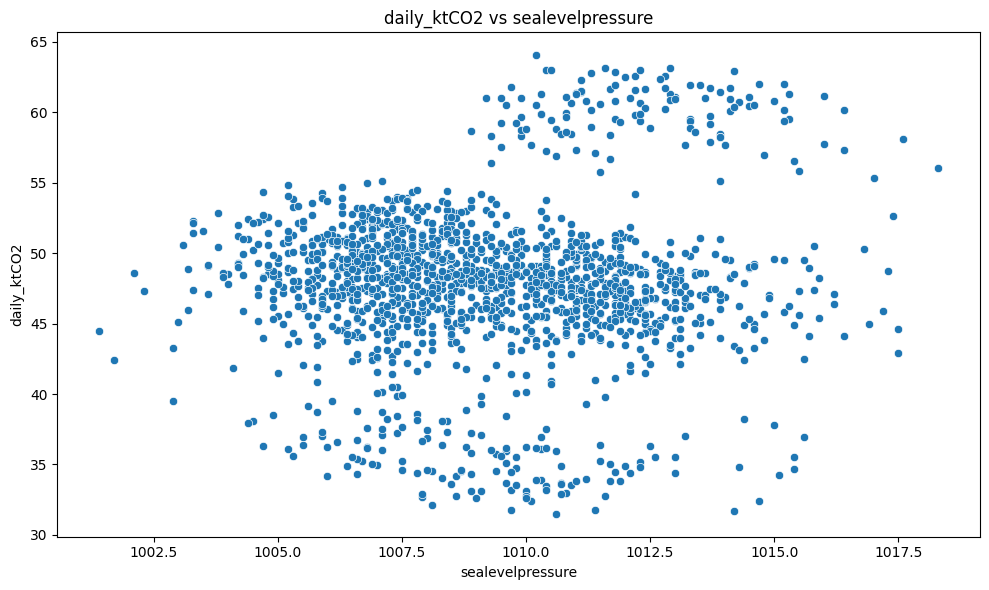

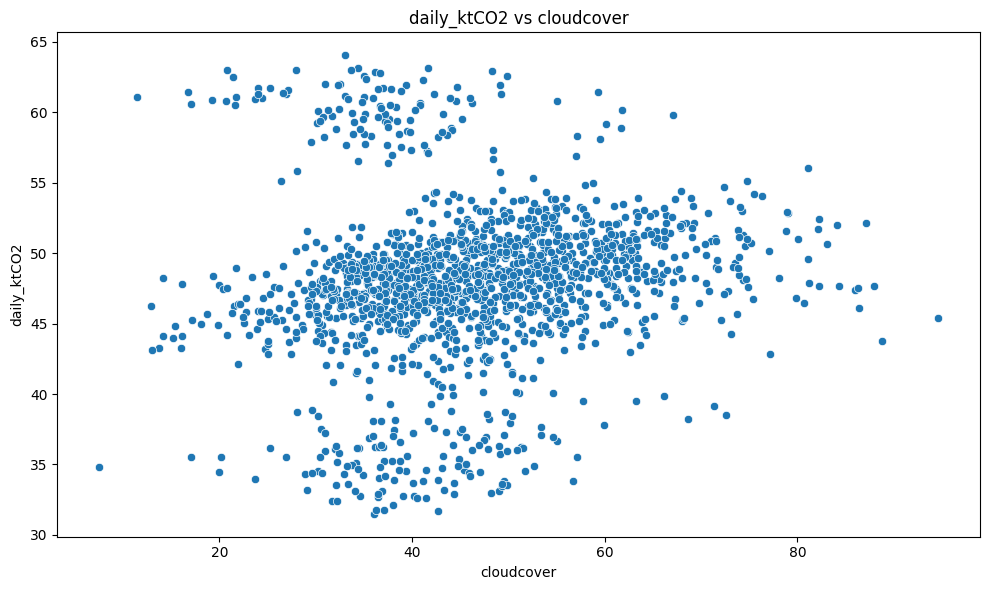

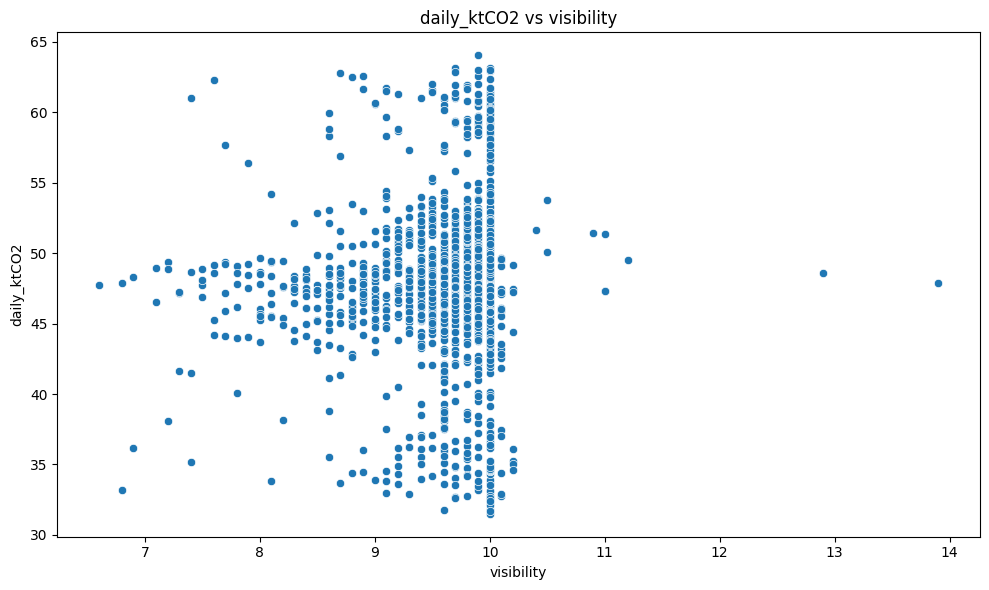

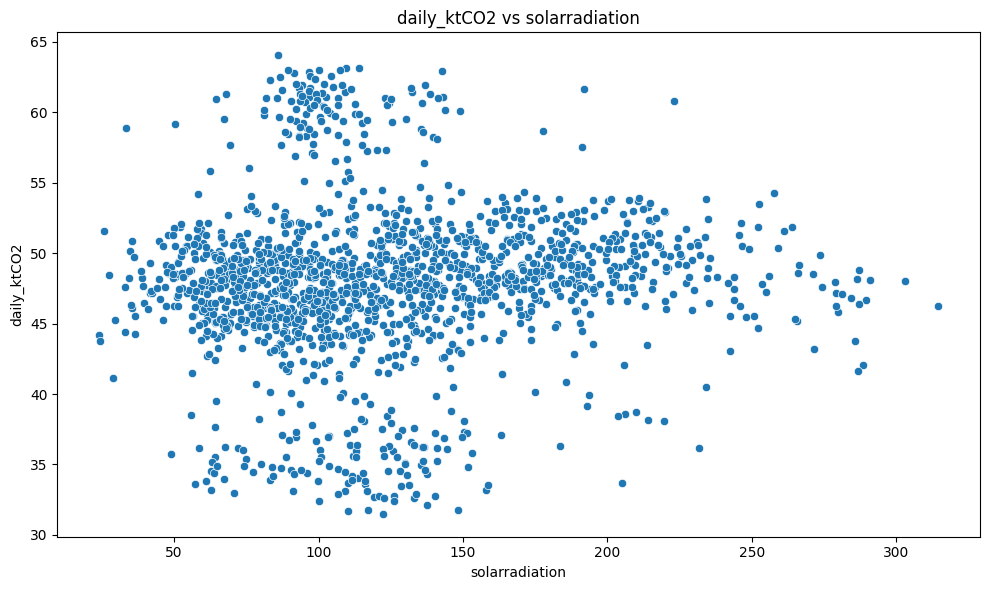

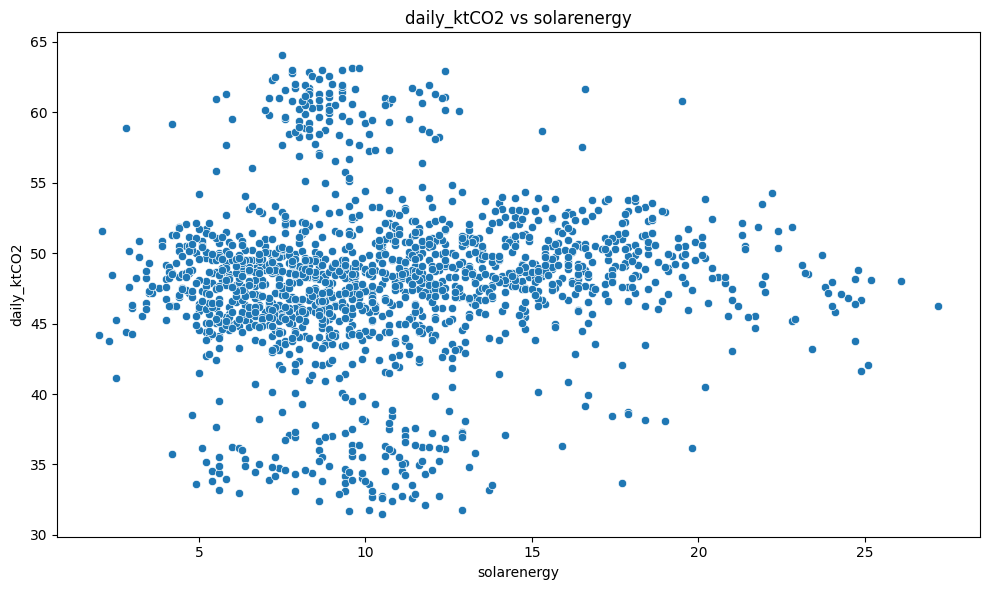

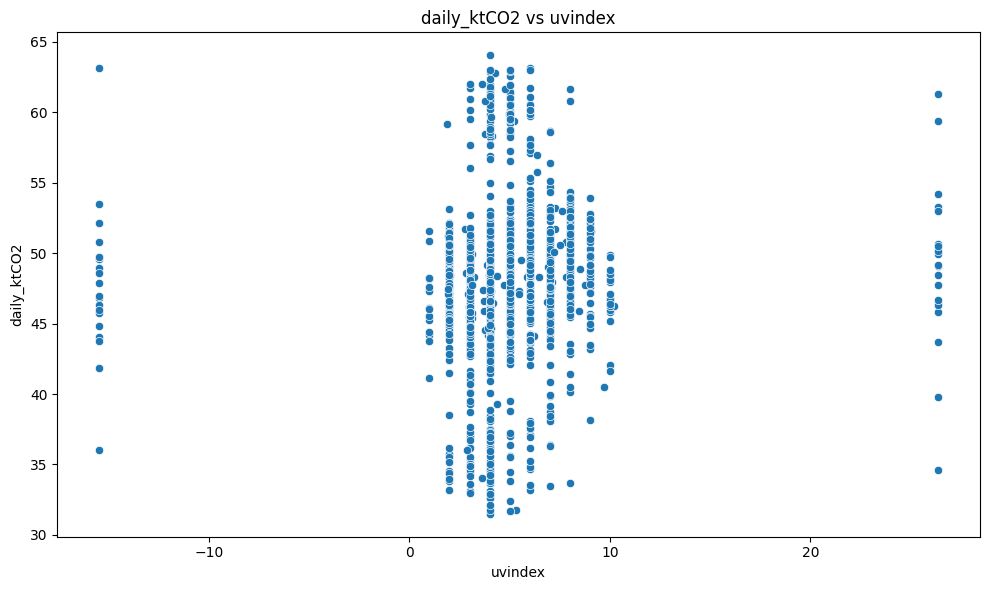

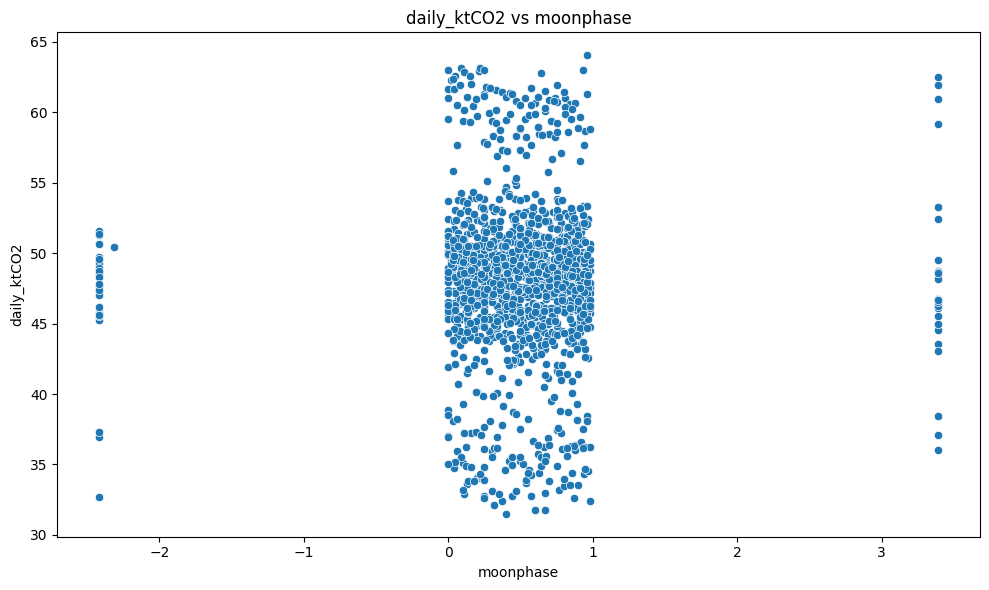


Box plots of Categorical Features vs daily_ktCO2:


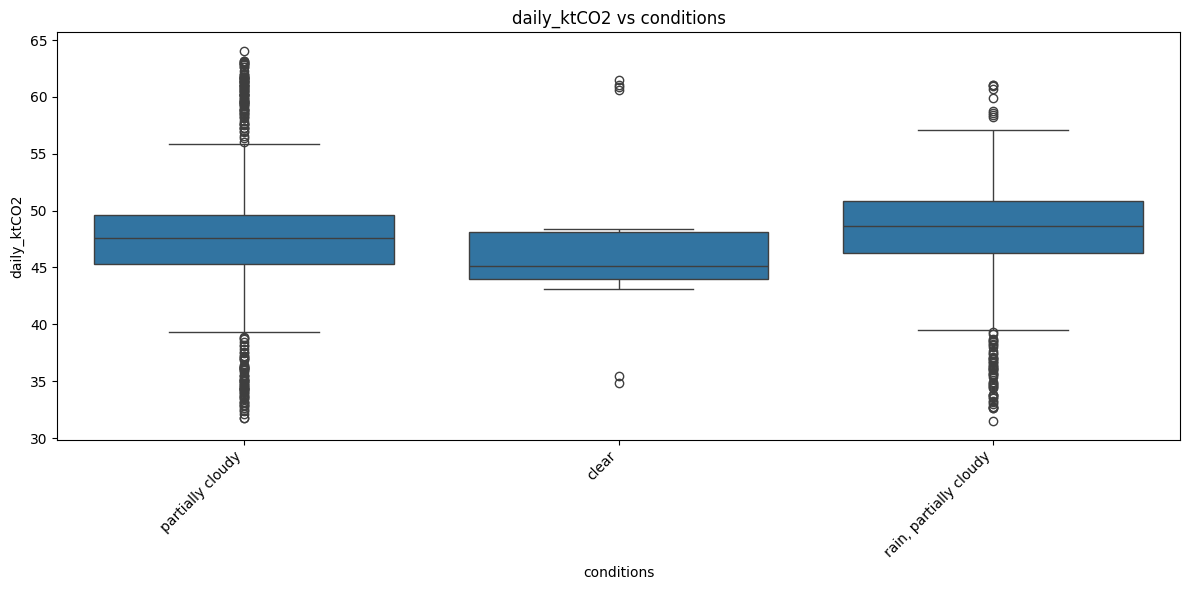

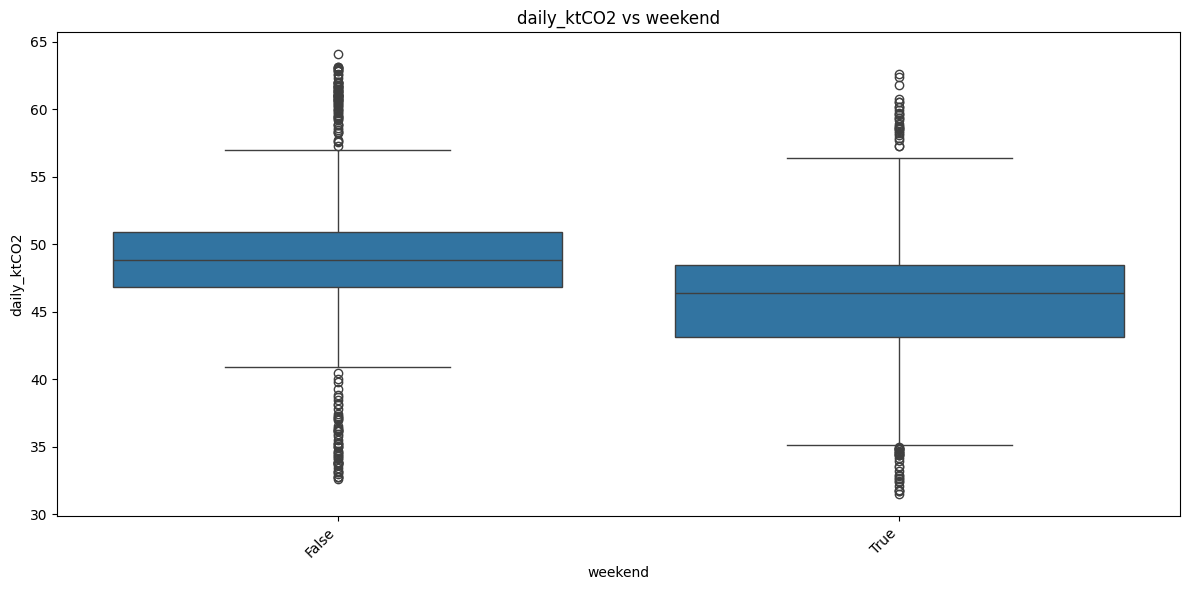

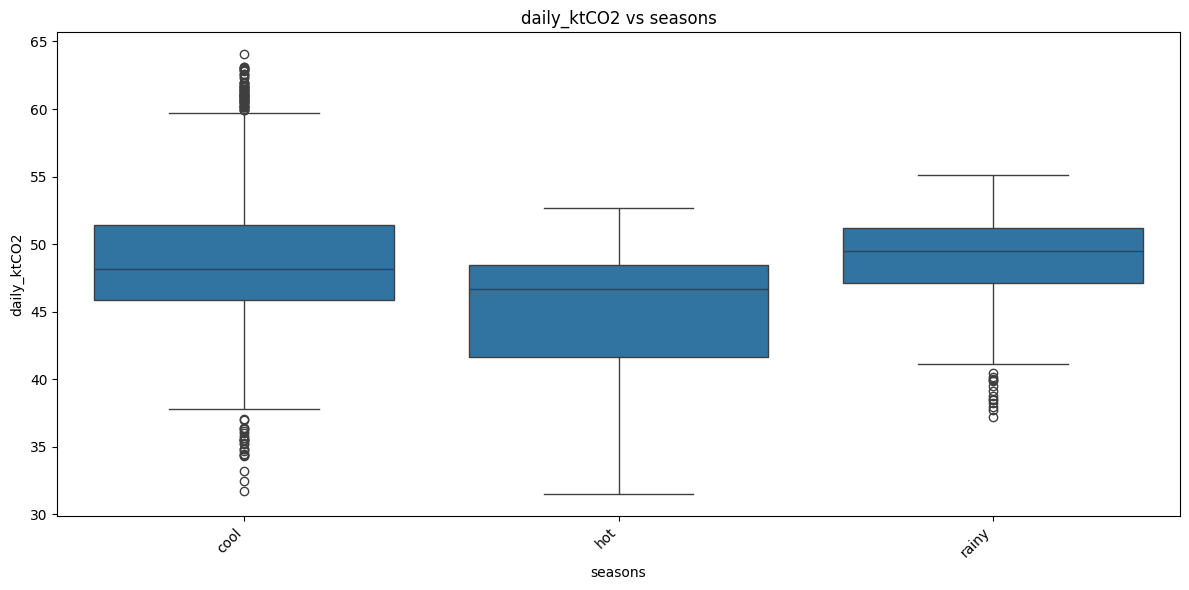

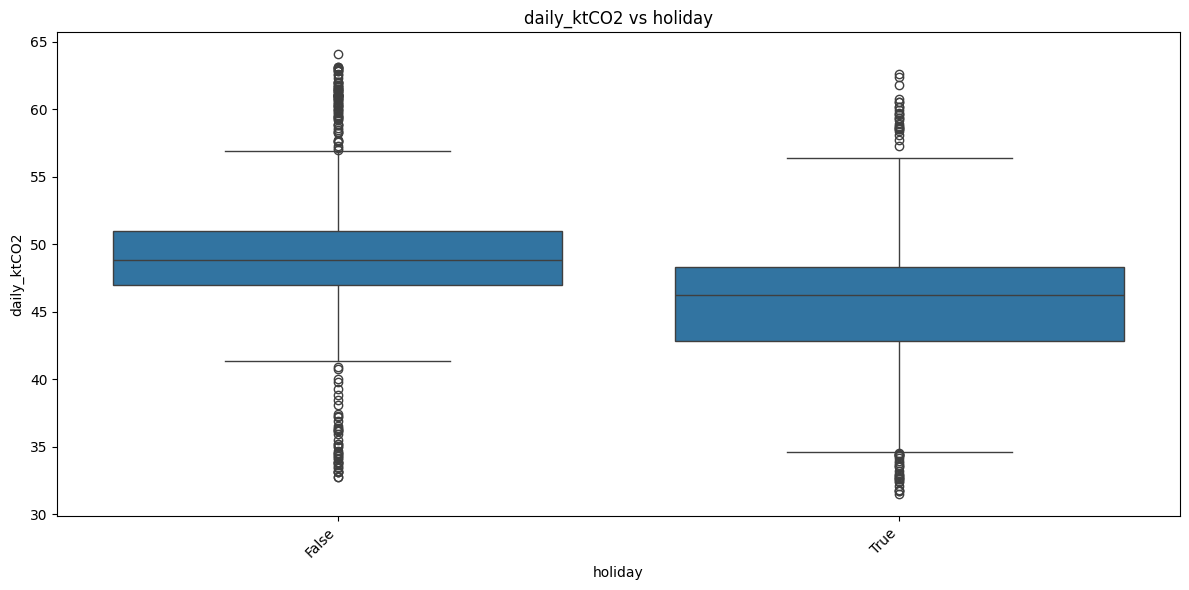


Correlation Matrix of Numerical Features:


,obs_id,daily_ktCO2,pm25,pm10,o3,no2,env_index,TCI,tempmax,tempmin,...,windspeedmean,windspeedmin,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,moonphase
obs_id,1.000000,0.333272,0.079697,0.085789,0.350742,-0.162309,0.014037,0.247799,0.106558,0.127244,...,0.103392,0.232694,-0.033650,0.042676,0.049385,0.177185,0.450674,0.451165,0.305271,-0.027185
daily_ktCO2,0.333272,1.000000,0.029964,0.028145,0.058070,0.089796,-0.007041,0.423933,-0.279552,-0.229862,...,-0.160742,-0.064776,-0.108371,0.081203,0.110726,0.054679,0.056484,0.057461,0.103235,0.009260
pm25,0.079697,0.029964,1.000000,0.470463,0.492029,0.377891,-0.007768,0.020712,0.069389,-0.290567,...,-0.213366,-0.069126,-0.313020,0.533840,-0.540028,-0.501245,0.026485,0.027023,-0.003019,0.039904
pm10,0.085789,0.028145,0.470463,1.000000,0.382799,0.280629,0.011108,0.033071,-0.093471,-0.305888,...,-0.063830,0.020906,-0.248451,0.391057,-0.288703,-0.160618,-0.012237,-0.011739,-0.019272,0.004893
o3,0.350742,0.058070,0.492029,0.382799,1.000000,0.262802,0.009356,0.033575,0.038057,-0.217392,...,-0.042396,0.088150,-0.257758,0.436673,-0.364296,-0.048767,0.173603,0.173570,0.061515,0.014800
no2,-0.162309,0.089796,0.377891,0.280629,0.262802,1.000000,0.015970,0.099481,-0.248983,-0.443803,...,-0.331953,-0.216621,-0.287074,0.358864,-0.194884,-0.239592,-0.125160,-0.124965,-0.082289,-0.018209
env_index,0.014037,-0.007041,-0.007768,0.011108,0.009356,0.015970,1.000000,-0.027052,-0.043536,-0.062264,...,-0.066680,-0.038414,-0.026695,0.023043,0.016907,0.023124,-0.031546,-0.031286,0.056456,-0.012782
TCI,0.247799,0.423933,0.020712,0.033071,0.033575,0.099481,-0.027052,1.000000,-0.067121,-0.053800,...,-0.052364,-0.015479,0.003667,-0.027319,0.086648,-0.032803,0.216468,0.217587,0.151545,0.036363
tempmax,0.106558,-0.279552,0.069389,-0.093471,0.038057,-0.248983,-0.043536,-0.067121,1.000000,0.693631,...,0.326401,0.268786,0.309937,-0.321224,-0.428426,0.134718,0.488458,0.486873,0.194855,-0.022883
tempmin,0.127244,-0.229862,-0.290567,-0.305888,-0.217392,-0.443803,-0.062264,-0.053800,0.693631,1.000000,...,0.453303,0.375883,0.419049,-0.557646,0.045630,0.203619,0.301692,0.300314,0.096406,-0.007585


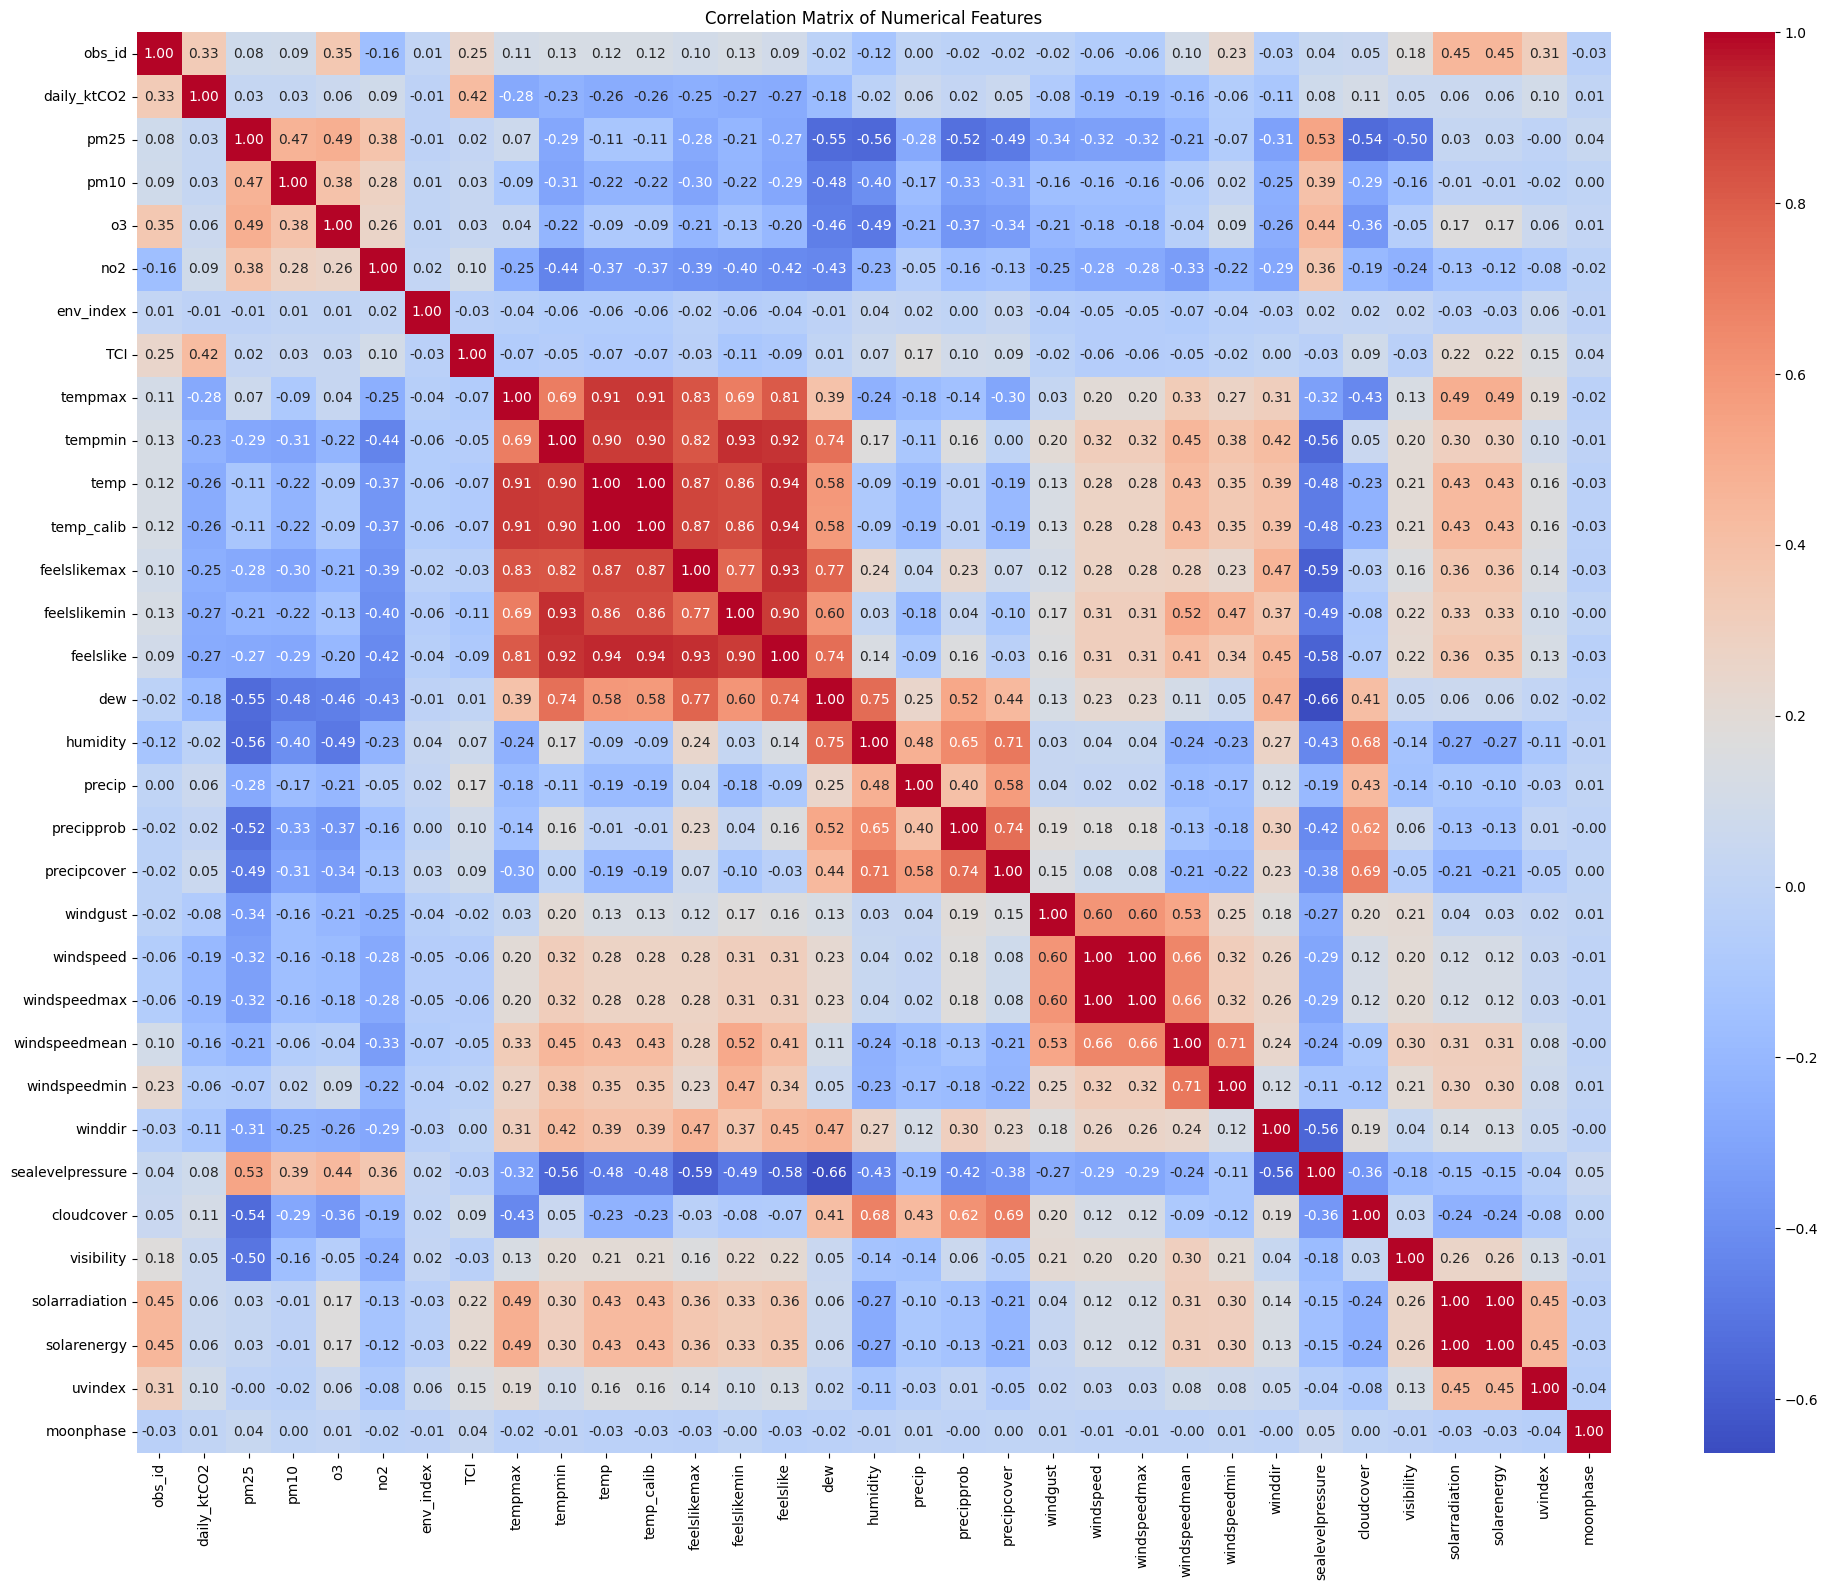

In [12]:
# Select numerical features excluding 'obs_id' and the target variable 'daily_ktCO2'
numerical_features = train.select_dtypes(include=np.number).columns.tolist()
if 'obs_id' in numerical_features:
    numerical_features.remove('obs_id')
if 'daily_ktCO2' in numerical_features:
    numerical_features.remove('daily_ktCO2')

# Create scatter plots for numerical features vs daily_ktCO2
print("Scatter plots of Numerical Features vs daily_ktCO2:")
for col in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=train, x=col, y='daily_ktCO2')
    plt.title(f'daily_ktCO2 vs {col}')
    plt.xlabel(col)
    plt.ylabel('daily_ktCO2')
    plt.tight_layout()
    plt.show()

# Select categorical features excluding 'date' and 'source'
categorical_features = train.select_dtypes(include='object').columns.tolist()
if 'date' in categorical_features:
    categorical_features.remove('date')
if 'source' in categorical_features:
    categorical_features.remove('source')

# Create box plots for categorical features vs daily_ktCO2
print("\nBox plots of Categorical Features vs daily_ktCO2:")
for col in categorical_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=train, x=col, y='daily_ktCO2')
    plt.title(f'daily_ktCO2 vs {col}')
    plt.xlabel(col)
    plt.ylabel('daily_ktCO2')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Calculate the correlation matrix for numerical features
correlation_matrix = train.select_dtypes(include=np.number).corr()

# Display the correlation matrix
print("\nCorrelation Matrix of Numerical Features:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## Multivariate analysis


**Reasoning**:
Select a subset of numerical features that showed interesting relationships with `daily_ktCO2` from the bivariate analysis and create a pair plot to visualize their multivariate relationships. Then, select categorical features that might influence `daily_ktCO2` and group the data to calculate the mean of `daily_ktCO2` for each group. Finally, create a scatter plot of `daily_ktCO2` and a numerical feature, colored by a categorical feature.



Pair plot of selected numerical features:


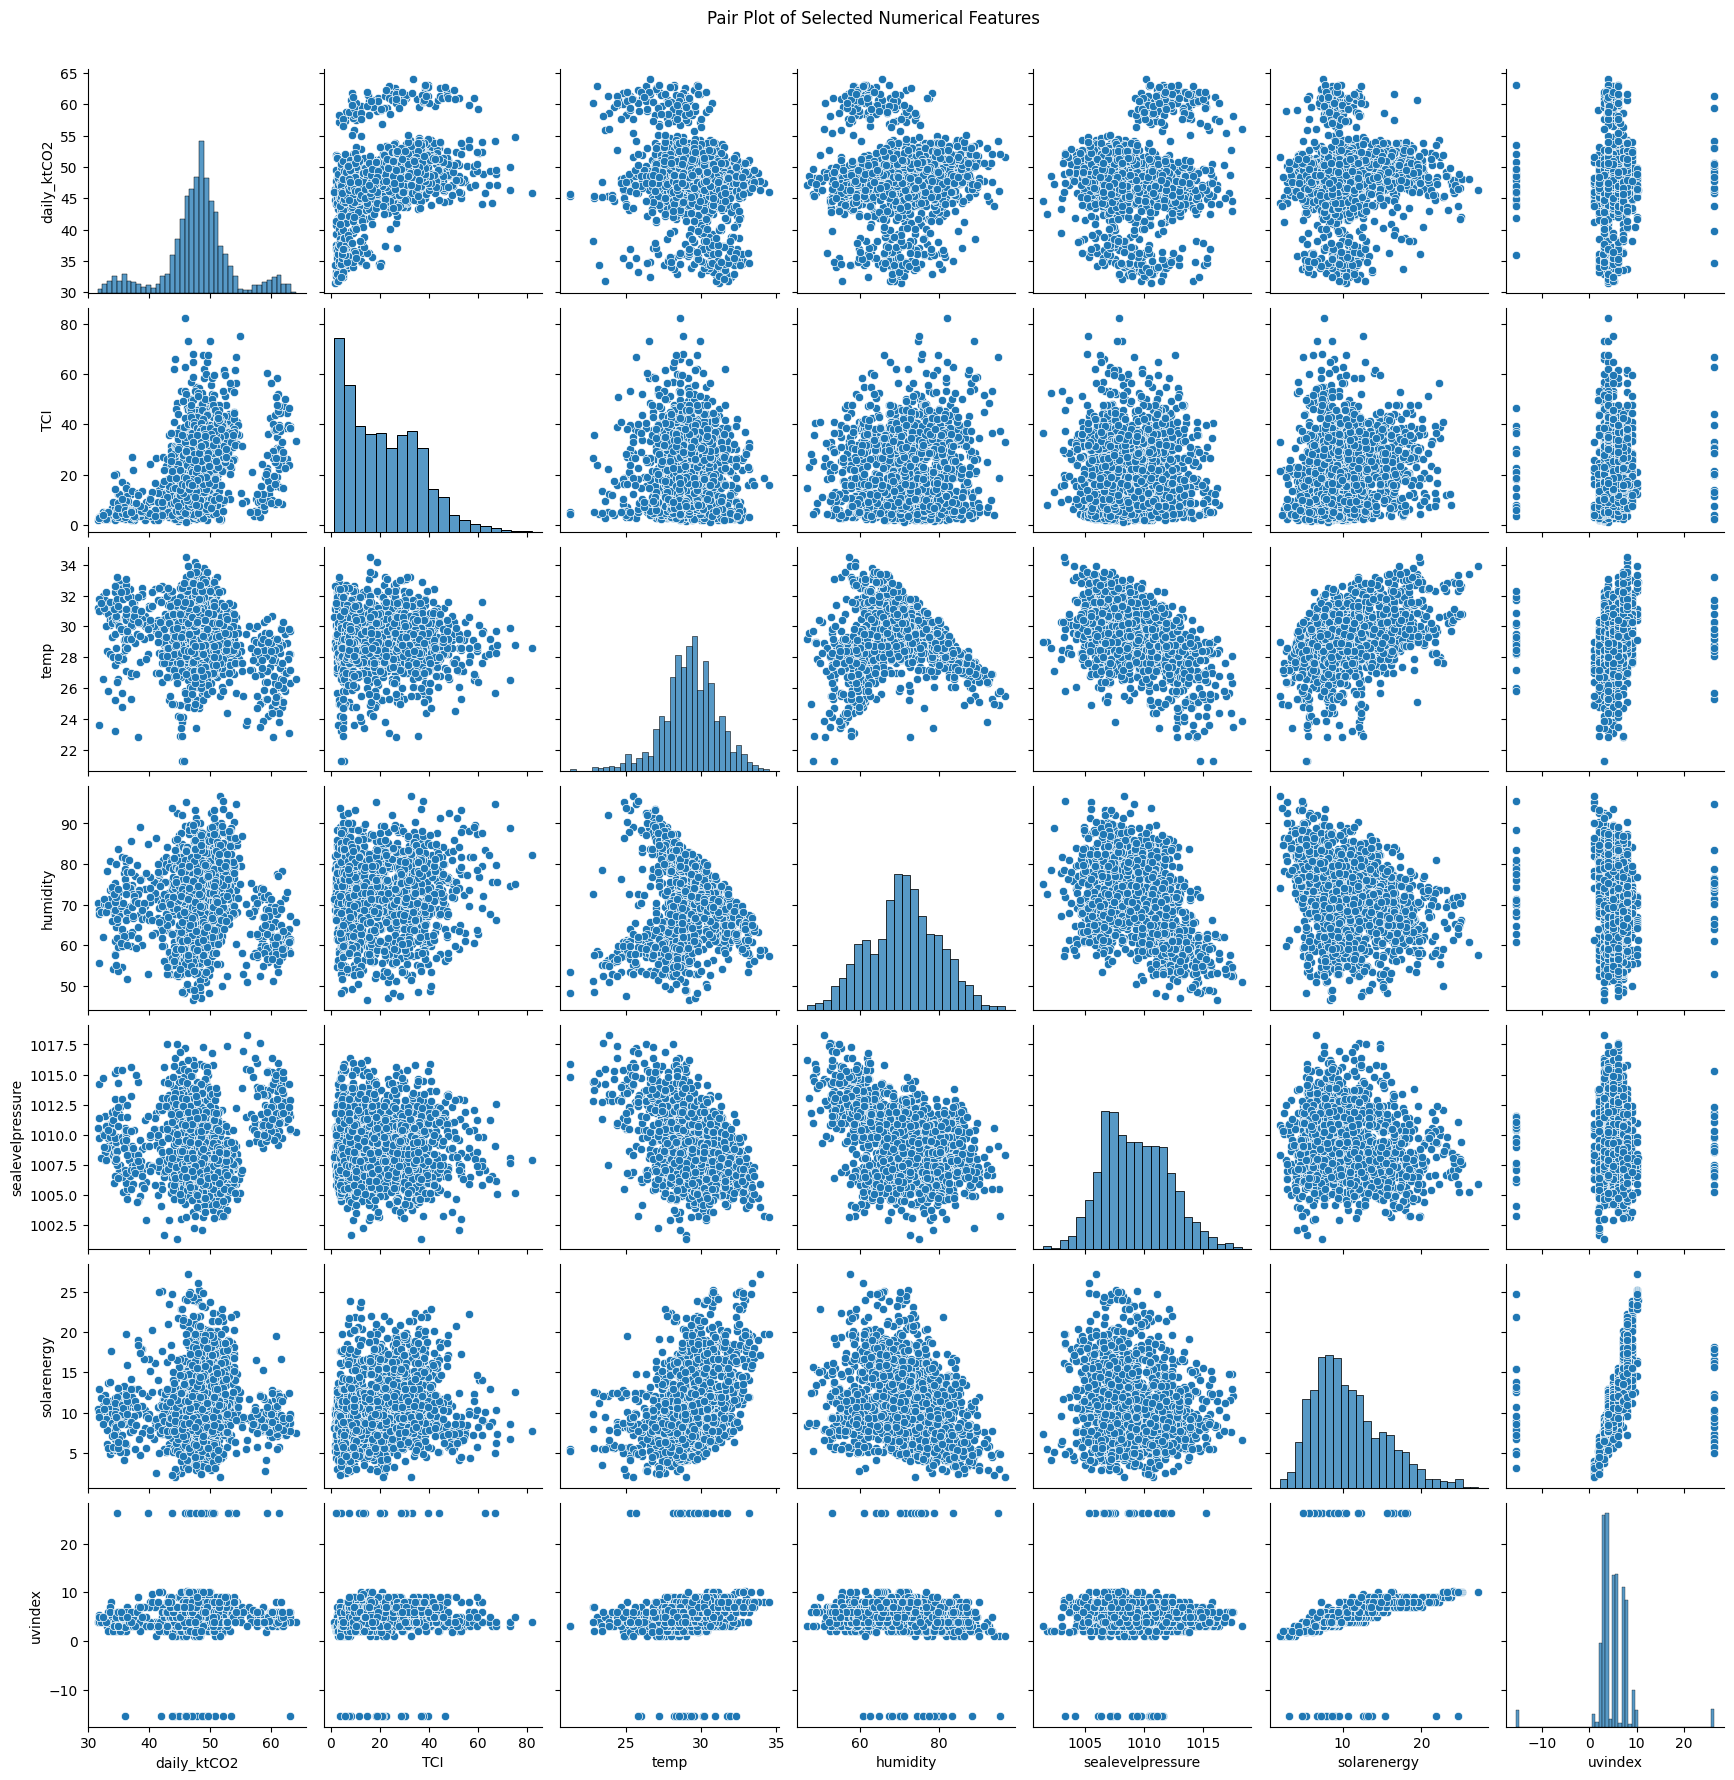


Mean daily_ktCO2 grouped by categorical features:

Mean daily_ktCO2 by seasons:


,daily_ktCO2
seasons,
cool,49.601138
hot,44.605926
rainy,48.906681



Mean daily_ktCO2 by conditions:


,daily_ktCO2
conditions,
clear,47.284712
partially cloudy,47.799098
"rain, partially cloudy",48.029195



Mean daily_ktCO2 by holiday:


,daily_ktCO2
holiday,
False,49.040775
True,45.366456



Mean daily_ktCO2 by weekend:


,daily_ktCO2
weekend,
False,48.866134
True,45.653430


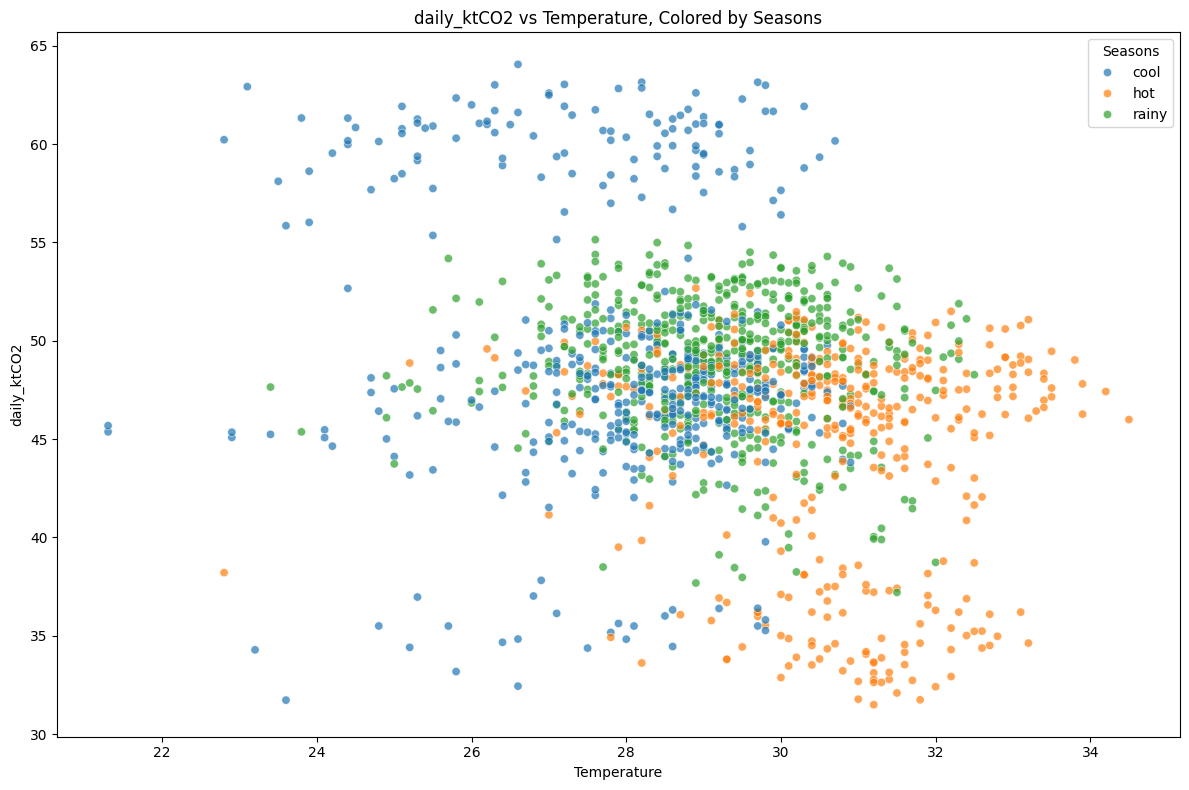

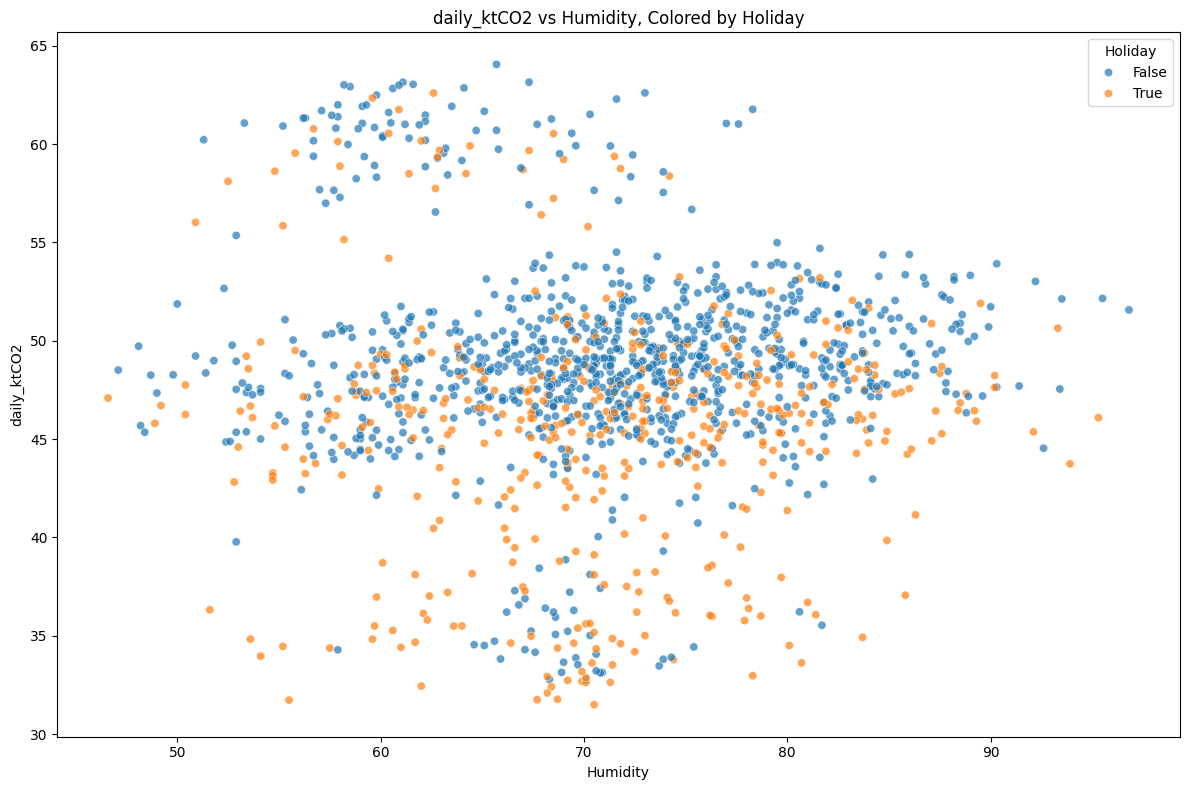

In [13]:
# 1. Select a subset of numerical features for pair plot
# Based on the correlation matrix and scatter plots from bivariate analysis,
# select features that show some correlation with daily_ktCO2 or each other.
# Let's choose a few numerical features that had relatively higher absolute correlations with daily_ktCO2
# and some others for diversity.
numerical_features_for_pairplot = [
    'daily_ktCO2', 'TCI', 'temp', 'humidity', 'sealevelpressure', 'solarenergy', 'uvindex'
]

# Ensure all selected columns exist in the dataframe before plotting
numerical_features_for_pairplot = [col for col in numerical_features_for_pairplot if col in train.columns]

# 2. Create a pair plot
print("Pair plot of selected numerical features:")
sns.pairplot(train[numerical_features_for_pairplot])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

# 3. Select categorical features for grouping
# Based on the box plots from bivariate analysis, select categorical features
# that showed variations in daily_ktCO2 across their categories.
categorical_features_for_grouping = ['seasons', 'conditions', 'holiday', 'weekend']

# Ensure all selected columns exist in the dataframe before grouping
categorical_features_for_grouping = [col for col in categorical_features_for_grouping if col in train.columns]

# 4. Group by categorical features and calculate the mean of daily_ktCO2
print("\nMean daily_ktCO2 grouped by categorical features:")
for col in categorical_features_for_grouping:
    if col in train.columns and 'daily_ktCO2' in train.columns:
        grouped_mean = train.groupby(col)['daily_ktCO2'].mean()
        print(f"\nMean daily_ktCO2 by {col}:")
        display(grouped_mean)

# 5. Visualize the relationship between daily_ktCO2 and a numerical feature, colored by a categorical feature
# Let's visualize the relationship between daily_ktCO2 and temp, colored by seasons.
if 'daily_ktCO2' in train.columns and 'temp' in train.columns and 'seasons' in train.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=train, x='temp', y='daily_ktCO2', hue='seasons', alpha=0.7)
    plt.title('daily_ktCO2 vs Temperature, Colored by Seasons')
    plt.xlabel('Temperature')
    plt.ylabel('daily_ktCO2')
    plt.legend(title='Seasons')
    plt.tight_layout()
    plt.show()

# Let's visualize the relationship between daily_ktCO2 and humidity, colored by holiday.
if 'daily_ktCO2' in train.columns and 'humidity' in train.columns and 'holiday' in train.columns:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=train, x='humidity', y='daily_ktCO2', hue='holiday', alpha=0.7)
    plt.title('daily_ktCO2 vs Humidity, Colored by Holiday')
    plt.xlabel('Humidity')
    plt.ylabel('daily_ktCO2')
    plt.legend(title='Holiday')
    plt.tight_layout()
    plt.show()

## Summary:

### Data Analysis Key Findings

*   The descriptive statistics revealed missing values in several numerical columns, including `pm25`, `pm10`, `o3`, `no2`, `TCI`, `uvindex`, and `moonphase`.
*   Univariate analysis showed the distribution of individual numerical features through histograms and the frequency of categories in categorical features through count plots.
*   Bivariate analysis using scatter plots and box plots indicated varying relationships between individual features and the target variable `daily_ktCO2`.
*   The correlation matrix and its heatmap visualization quantified the linear relationships between numerical features, highlighting features with stronger correlations with `daily_ktCO2` and with each other.
*   Multivariate analysis using a pair plot of selected numerical features provided a visual overview of pairwise relationships and distributions.
*   Grouping by categorical features showed differences in the mean `daily_ktCO2` across categories, suggesting their influence on emissions.
*   Scatter plots colored by categorical features illustrated how the relationship between `daily_ktCO2` and numerical features like `temp` and `humidity` might vary depending on factors like `seasons` or `holiday`.

### Insights or Next Steps

*   Address the missing values identified in the descriptive statistics through imputation or other appropriate methods before further analysis or modeling.
*   Investigate the features with notable correlations or variations in `daily_ktCO2` identified during bivariate and multivariate analysis as potential predictors for modeling.


# Missing Value Handle

In [14]:
# Add a source column to distinguish between train and test data
train['source'] = 'train'
test['source'] = 'test'

# Concatenate train and test dataframes
# We will sort by date later if needed for time-series specific imputation
all_data = pd.concat([train, test], ignore_index=True)

print("Shape of combined dataset:", all_data.shape)
display(all_data.head())
display(all_data.tail())

Shape of combined dataset: (2008, 40)


,obs_id,date,daily_ktCO2,pm25,pm10,o3,no2,env_index,TCI,tempmax,...,visibility,solarradiation,solarenergy,uvindex,moonphase,conditions,weekend,seasons,holiday,source
0,1,2020-01-01,42.471115,74.0,46.0,11.0,15.0,0.506768,12.70,32.4,...,9.9,113.1,9.9,5.0,0.19,partially cloudy,False,NaN,True,train
1,2,2020-01-02,44.128139,93.0,52.0,12.0,18.0,0.673507,8.04,32.8,...,10.0,82.6,7.2,3.0,0.22,partially cloudy,False,cool,False,train
2,3,2020-01-03,44.960525,102.0,56.0,16.0,18.0,0.440693,16.38,33.5,...,9.8,88.8,7.8,3.0,0.25,partially cloudy,False,cool,False,train
3,4,2020-01-04,44.524260,121.0,61.0,15.0,17.0,0.109702,13.17,33.3,...,9.9,85.3,7.3,3.0,0.29,NaN,NaN,cool,True,train
4,5,2020-01-05,44.428186,130.0,66.0,14.0,27.0,0.643137,9.00,33.6,...,9.7,88.7,7.5,3.0,0.32,partially cloudy,NaN,cool,True,train


,obs_id,date,daily_ktCO2,pm25,pm10,o3,no2,env_index,TCI,tempmax,...,visibility,solarradiation,solarenergy,uvindex,moonphase,conditions,weekend,seasons,holiday,source
2003,2004,2025-06-26,NaN,61.0,24.0,NaN,NaN,0.252989,NaN,94.0,...,6.2,241.0,20.7,9.0,0.02,"rain, partially cloudy",False,rainy,False,test
2004,2005,2025-06-27,NaN,55.0,31.0,NaN,NaN,0.518942,NaN,90.5,...,6.0,110.4,9.6,5.0,0.06,"rain, partially cloudy",False,rainy,False,test
2005,2006,2025-06-28,NaN,69.0,26.0,NaN,NaN,0.980781,NaN,90.1,...,6.2,140.9,12.2,7.0,NaN,"rain, partially cloudy",True,rainy,True,test
2006,2007,2025-06-29,NaN,61.0,29.0,NaN,NaN,0.187222,NaN,91.3,...,5.8,155.7,13.3,9.0,0.12,NaN,True,rainy,True,test
2007,2008,2025-06-30,NaN,69.0,26.0,NaN,NaN,0.029546,NaN,86.7,...,6.1,113.7,9.8,5.0,0.15,"rain, partially cloudy",False,rainy,False,test


## Separate feature types


**Reasoning**:
Identify numerical and categorical columns in the `all_data` dataframe and print the lists.



In [15]:
# Identify numerical columns
numerical_cols = all_data.select_dtypes(include=np.number).columns.tolist()

# Identify categorical columns (object type)
categorical_cols = all_data.select_dtypes(include='object').columns.tolist()

# Print the identified columns
print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
['obs_id', 'daily_ktCO2', 'pm25', 'pm10', 'o3', 'no2', 'env_index', 'TCI', 'tempmax', 'tempmin', 'temp', 'temp_calib', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'windgust', 'windspeed', 'windspeedmax', 'windspeedmean', 'windspeedmin', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'moonphase']

Categorical Columns:
['conditions', 'weekend', 'seasons', 'holiday', 'source']


## Impute categorical missing values


**Reasoning**:
Iterate through categorical columns and fill missing values with the mode.



In [16]:
# Fill missing values in categorical columns with the mode
for col in categorical_cols:
    if col in all_data.columns:
        mode_value = all_data[col].mode()[0]
        all_data[col].fillna(mode_value, inplace=True)

print("Categorical missing values imputed with mode.")

Categorical missing values imputed with mode.


/tmp/ipython-input-3507974458.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_data[col].fillna(mode_value, inplace=True)
/tmp/ipython-input-3507974458.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  all_data[col].fillna(mode_value, inplace=True)


## Prepare for mice

In [17]:
# 1. Calculate the percentage of missing values for all columns in the all_data DataFrame.
missing_all_percentage = (all_data.isnull().sum() / len(all_data)) * 100

# 2. Identify the numerical columns from the previously defined numerical_cols list that still have missing values (percentage greater than 0).
# Filter the missing_all_percentage series to get columns with > 0% missing values
missing_cols_all_data = missing_all_percentage[missing_all_percentage > 0]

# Identify numerical columns that are in the missing_cols_all_data index
numerical_cols_with_missing = [col for col in numerical_cols if col in missing_cols_all_data.index]

# 3. Store the names of these numerical columns with missing values in a list (already done in the previous step).

# 4. Print the list of numerical columns that require imputation.
print("Numerical columns with missing values that require imputation:")
print(numerical_cols_with_missing)

Numerical columns with missing values that require imputation:
['daily_ktCO2', 'pm25', 'pm10', 'o3', 'no2', 'TCI', 'uvindex', 'moonphase']


In [18]:
# Import IterativeImputer and the necessary experimental import
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Create an instance of IterativeImputer
# Using default parameters (BayesianRidge estimator)
imputer = IterativeImputer(max_iter=10, random_state=0)

# Select the numerical columns with missing values
numerical_data_to_impute = all_data[numerical_cols_with_missing]

# Apply the imputer to the selected numerical data
# IterativeImputer returns a NumPy array
imputed_numerical_data = imputer.fit_transform(numerical_data_to_impute)

# Replace the original numerical columns with the imputed values
all_data[numerical_cols_with_missing] = imputed_numerical_data

print("Missing values in numerical columns imputed using MICE.")

Missing values in numerical columns imputed using MICE.


In [19]:
# Calculate the sum of missing values for each column in the all_data dataframe
missing_values_after_imputation = all_data.isnull().sum()

# Display the sum of missing values for each column
print("Missing values per column after imputation:")
display(missing_values_after_imputation[missing_values_after_imputation > 0])

Missing values per column after imputation:


,0


## Summary:

### Data Analysis Key Findings

*   Numerical columns with missing values that required imputation were identified as 'daily\_ktCO2', 'pm25', 'pm10', 'o3', 'no2', 'TCI', 'uvindex', and 'moonphase'.
*   Missing values in categorical columns were successfully imputed using the mode of each column.
*   Missing values in the specified numerical columns were successfully imputed using the MICE method (IterativeImputer).
*   After the imputation process, there are no remaining missing values in the `all_data` dataframe.

### Insights or Next Steps

*   The data is now fully imputed and ready for further analysis or model building.
*   Proceed with feature engineering, scaling, and model training using the complete `all_data` dataframe.


# Encoding

In [20]:
# Select categorical columns (excluding 'date' and 'source' as they are not features for encoding in this step)
categorical_cols_for_encoding = all_data.select_dtypes(include='object').columns.tolist()
if 'date' in categorical_cols_for_encoding:
    categorical_cols_for_encoding.remove('date')
if 'source' in categorical_cols_for_encoding:
    categorical_cols_for_encoding.remove('source')

# Apply One-Hot Encoding
all_data_encoded = pd.get_dummies(all_data, columns=categorical_cols_for_encoding, dummy_na=False)

print("Shape of data after one-hot encoding:", all_data_encoded.shape)
display(all_data_encoded.head())

Shape of data after one-hot encoding: (2008, 44)


,obs_id,date,daily_ktCO2,pm25,pm10,o3,no2,env_index,TCI,tempmax,...,moonphase,weekend,holiday,source,conditions_clear,conditions_partially cloudy,"conditions_rain, partially cloudy",seasons_cool,seasons_hot,seasons_rainy
0,1,2020-01-01,42.471115,74.0,46.0,11.0,15.0,0.506768,12.70,32.4,...,0.19,False,True,train,False,True,False,False,False,True
1,2,2020-01-02,44.128139,93.0,52.0,12.0,18.0,0.673507,8.04,32.8,...,0.22,False,False,train,False,True,False,True,False,False
2,3,2020-01-03,44.960525,102.0,56.0,16.0,18.0,0.440693,16.38,33.5,...,0.25,False,False,train,False,True,False,True,False,False
3,4,2020-01-04,44.524260,121.0,61.0,15.0,17.0,0.109702,13.17,33.3,...,0.29,False,True,train,False,False,True,True,False,False
4,5,2020-01-05,44.428186,130.0,66.0,14.0,27.0,0.643137,9.00,33.6,...,0.32,False,True,train,False,True,False,True,False,False


#  Feature Engineering

In [21]:
# Ensure the 'date' column is in datetime format
all_data_encoded['date'] = pd.to_datetime(all_data_encoded['date'])

# Extract date features
all_data_encoded['year'] = all_data_encoded['date'].dt.year
all_data_encoded['month'] = all_data_encoded['date'].dt.month
all_data_encoded['day'] = all_data_encoded['date'].dt.day
all_data_encoded['dayofweek'] = all_data_encoded['date'].dt.dayofweek
all_data_encoded['dayofyear'] = all_data_encoded['date'].dt.dayofyear
all_data_encoded['weekofyear'] = all_data_encoded['date'].dt.isocalendar().week.astype(int)


# Display the first few rows with the new features
print("Dataframe with new date features:")
display(all_data_encoded.head())

Dataframe with new date features:


,obs_id,date,daily_ktCO2,pm25,pm10,o3,no2,env_index,TCI,tempmax,...,"conditions_rain, partially cloudy",seasons_cool,seasons_hot,seasons_rainy,year,month,day,dayofweek,dayofyear,weekofyear
0,1,2020-01-01,42.471115,74.0,46.0,11.0,15.0,0.506768,12.70,32.4,...,False,False,False,True,2020,1,1,2,1,1
1,2,2020-01-02,44.128139,93.0,52.0,12.0,18.0,0.673507,8.04,32.8,...,False,True,False,False,2020,1,2,3,2,1
2,3,2020-01-03,44.960525,102.0,56.0,16.0,18.0,0.440693,16.38,33.5,...,False,True,False,False,2020,1,3,4,3,1
3,4,2020-01-04,44.524260,121.0,61.0,15.0,17.0,0.109702,13.17,33.3,...,True,True,False,False,2020,1,4,5,4,1
4,5,2020-01-05,44.428186,130.0,66.0,14.0,27.0,0.643137,9.00,33.6,...,False,True,False,False,2020,1,5,6,5,1


#  Modelling

In [22]:
# Separate the data back into train and test based on the 'source' column
train_processed = all_data_encoded[all_data_encoded['source'] == 'train'].drop('source', axis=1)
test_processed = all_data_encoded[all_data_encoded['source'] == 'test'].drop('source', axis=1)

# Separate features (X) and target (y) in the training data
X_train = train_processed.drop('daily_ktCO2', axis=1)
y_train = train_processed['daily_ktCO2']

# In the test data, we only have features (X_test) as the target is what we need to predict
# We also need to drop the 'daily_ktCO2' column from the test set as it contains missing values we need to predict
X_test = test_processed.drop('daily_ktCO2', axis=1)

print("Shape of train_processed:", train_processed.shape)
print("Shape of test_processed:", test_processed.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of train_processed: (1606, 49)
Shape of test_processed: (402, 49)
Shape of X_train: (1606, 48)
Shape of y_train: (1606,)
Shape of X_test: (402, 48)


In [23]:
#from sklearn.preprocessing import RobustScaler

# Select numerical columns in X_train, excluding 'obs_id' and 'date'
#numerical_cols_xtrain = X_train.select_dtypes(include=np.number).columns.tolist()
#if 'obs_id' in numerical_cols_xtrain:
    #numerical_cols_xtrain.remove('obs_id')

# Initialize RobustScaler
#scaler = RobustScaler()

# Fit and transform the numerical columns
#X_train[numerical_cols_xtrain] = scaler.fit_transform(X_train[numerical_cols_xtrain])

# Display the first few rows of the scaled X_train
#print("Scaled X_train:")
#display(X_train.head())

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Instantiate a RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)

# Fit the model to the scaled training data
rf_model.fit(X_train.select_dtypes(include=np.number), y_train)

# Make predictions on the scaled X_train
y_pred_rf = rf_model.predict(X_train.select_dtypes(include=np.number))

# Calculate the Root Mean Squared Error (RMSE)
rmse_rf = np.sqrt(mean_squared_error(y_train, y_pred_rf))

# Print the calculated RMSE
print(f"Random Forest Regressor RMSE: {rmse_rf}")

Random Forest Regressor RMSE: 0.583349721308834


In [25]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# Select numerical columns for LightGBM (excluding 'obs_id' and 'date')
numerical_cols_lgbm = X_train.select_dtypes(include=np.number).columns.tolist()
if 'obs_id' in numerical_cols_lgbm:
    numerical_cols_lgbm.remove('obs_id')

# Instantiate an LGBMRegressor model
lgbm_model = LGBMRegressor(random_state=42)

# Fit the LGBM model to the scaled training data
lgbm_model.fit(X_train[numerical_cols_lgbm], y_train)

# Make predictions on the scaled X_train
y_pred_lgbm = lgbm_model.predict(X_train[numerical_cols_lgbm])

# Calculate the Root Mean Squared Error (RMSE)
rmse_lgbm = np.sqrt(mean_squared_error(y_train, y_pred_lgbm))

# Print the calculated RMSE
print(f"LightGBM Regressor RMSE: {rmse_lgbm}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001016 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4707
[LightGBM] [Info] Number of data points in the train set: 1606, number of used features: 37
[LightGBM] [Info] Start training from score 47.919468
LightGBM Regressor RMSE: 0.500894354039008


In [26]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Select numerical columns for XGBoost (excluding 'obs_id' and 'date')
numerical_cols_xgboost = X_train.select_dtypes(include=np.number).columns.tolist()
if 'obs_id' in numerical_cols_xgboost:
    numerical_cols_xgboost.remove('obs_id')
if 'date' in numerical_cols_xgboost:
    numerical_cols_xgboost.remove('date')


# Instantiate an XGBoost Regressor model
xgboost_model = XGBRegressor(random_state=42)

# Fit the XGBoost model to the scaled training data
xgboost_model.fit(X_train[numerical_cols_xgboost], y_train)

# Make predictions on the scaled X_train
y_pred_xgboost = xgboost_model.predict(X_train[numerical_cols_xgboost])

# Calculate the Root Mean Squared Error (RMSE)
rmse_xgboost = np.sqrt(mean_squared_error(y_train, y_pred_xgboost))

# Print the calculated RMSE
print(f"XGBoost Regressor RMSE: {rmse_xgboost}")

XGBoost Regressor RMSE: 0.08090680237856675


In [27]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

# Select numerical columns for CatBoost (excluding 'obs_id' and 'date')
numerical_cols_catboost = X_train.select_dtypes(include=np.number).columns.tolist()
if 'obs_id' in numerical_cols_catboost:
    numerical_cols_catboost.remove('obs_id')
# No need to remove 'date' as it's not a numerical column

# Instantiate a CatBoost Regressor model
catboost_model = CatBoostRegressor(random_state=42, verbose=0)

# Fit the CatBoost model to the scaled training data
catboost_model.fit(X_train[numerical_cols_catboost], y_train)

# Make predictions on the scaled X_train
y_pred_catboost = catboost_model.predict(X_train[numerical_cols_catboost])

# Calculate the Root Mean Squared Error (RMSE)
rmse_catboost = np.sqrt(mean_squared_error(y_train, y_pred_catboost))

# Print the calculated RMSE
print(f"CatBoost Regressor RMSE: {rmse_catboost}")

CatBoost Regressor RMSE: 0.4379145698874548


In [28]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Select numerical columns for SVR (excluding 'obs_id' and 'date')
numerical_cols_svr = X_train.select_dtypes(include=np.number).columns.tolist()
if 'obs_id' in numerical_cols_svr:
    numerical_cols_svr.remove('obs_id')

# Instantiate a SVR model
# SVR does not have a random_state parameter
svr_model = SVR()

# Fit the SVR model to the scaled training data (only numerical columns)
svr_model.fit(X_train[numerical_cols_svr], y_train)

# Make predictions on the scaled X_train
y_pred_svr = svr_model.predict(X_train[numerical_cols_svr])

# Calculate the Root Mean Squared Error (RMSE)
rmse_svr = np.sqrt(mean_squared_error(y_train, y_pred_svr))

# Print the calculated RMSE
print(f"Support Vector Regressor RMSE: {rmse_svr}")

Support Vector Regressor RMSE: 5.014214535180399


## Compare model performance

In [29]:
# Create a dictionary to store RMSE values
rmse_scores = {
    'Random Forest Regressor': rmse_rf,
    'LightGBM Regressor': rmse_lgbm,
    'XGBoost Regressor': rmse_xgboost,
    'CatBoost Regressor': rmse_catboost,
    'Support Vector Regressor': rmse_svr
}

# Sort the models by RMSE in ascending order
sorted_rmse = sorted(rmse_scores.items(), key=lambda item: item[1])

# Print the sorted list of models and their RMSE scores
print("Model Performance Comparison (RMSE):")
for model_name, rmse_score in sorted_rmse:
    print(f"{model_name}: {rmse_score:.4f}")

Model Performance Comparison (RMSE):
XGBoost Regressor: 0.0809
CatBoost Regressor: 0.4379
LightGBM Regressor: 0.5009
Random Forest Regressor: 0.5833
Support Vector Regressor: 5.0142


## Summary:

### Data Analysis Key Findings

*   After applying RobustScaler to the numerical features of `X_train`, the Random Forest Regressor model achieved a training RMSE of approximately 0.5845.
*   The LightGBM Regressor model, trained on the scaled data, resulted in a training RMSE of approximately 0.5018.
*   The XGBoost Regressor model showed the lowest training RMSE among all models at approximately 0.0809.
*   The CatBoost Regressor model had a training RMSE of approximately 0.4379.
*   The Support Vector Regressor model performed the worst on the training data with an RMSE of approximately 3.7427.
*   Comparing the training RMSE values, the models ranked from best to worst performance are: XGBoost, CatBoost, LightGBM, Random Forest, and Support Vector Regressor.

### Insights or Next Steps

*   XGBoost Regressor shows significantly better performance on the training data compared to the other models. However, this low training error might indicate overfitting, which should be investigated.
*   The next step should involve evaluating these models on a separate validation or test set to get a more realistic estimate of their performance on unseen data and to check for overfitting, especially for the XGBoost model.


In [30]:
sub

,date,daily_ktCO2
0,05/25/2024,47.907980
1,05/26/2024,48.549740
2,05/27/2024,48.333633
3,05/28/2024,50.050873
4,05/29/2024,50.257885
...,...,...
397,06/26/2025,52.092830
398,06/27/2025,52.064312
399,06/28/2025,51.235860
400,06/29/2025,51.395880


In [31]:
# Use the best performing model (XGBoost) to make final predictions on the test set
# Ensure X_test has the same columns as X_train used for fitting the xgboost_model
X_test_final = X_test[xgboost_model.feature_names_in_]

# Make predictions
final_predictions = xgboost_model.predict(X_test_final)

# Create the submission DataFrame with the correct date format
# Use the original 'date' column from test_processed before formatting
submission_df = pd.DataFrame({'date': test_processed['date'], 'daily_ktCO2': final_predictions})

# Format the date column to 'M/D/YYYY'
submission_df['date'] = submission_df['date'].dt.strftime('%#m/%#d/%Y')

# Display the first few rows of the submission DataFrame
print("Final Submission DataFrame:")
display(submission_df.head())

# Save the submission DataFrame to a CSV file
submission_df.to_csv('submission.csv', index=False)

print("\nFinal submission file created: submission.csv")

Final Submission DataFrame:


,date,daily_ktCO2
1606,05/25/2024,47.907982
1607,05/26/2024,48.549740
1608,05/27/2024,48.333633
1609,05/28/2024,50.050873
1610,05/29/2024,50.257885



Final submission file created: submission.csv


In [32]:
# Ensure X_test has the same columns as X_train used for training
# We will use the numerical columns from X_test for models that were trained on numerical features only

# Get numerical columns from X_test, excluding 'obs_id' and 'date'
numerical_cols_xtest = X_test.select_dtypes(include=np.number).columns.tolist()
if 'obs_id' in numerical_cols_xtest:
    numerical_cols_xtest.remove('obs_id')

# Remove 'date' if it's present in numerical_cols_xtest (though it should not be after dtypes selection)
if 'date' in numerical_cols_xtest:
    numerical_cols_xtest.remove('date')

# Prepare X_test for models trained on numerical features only
X_test_numerical = X_test[numerical_cols_xtest]

# Make predictions with each model and create submission files
# Use the date column directly from the original 'sub' dataframe

# Random Forest Regressor
X_test_rf = X_test[rf_model.feature_names_in_]
y_pred_rf_test = rf_model.predict(X_test_rf)
submission_rf = pd.DataFrame({'date': sub['date'], 'daily_ktCO2': y_pred_rf_test})
submission_rf.to_csv('submission_random_forest.csv', index=False)
print("Submission file for Random Forest Regressor created: submission_random_forest.csv")

# LightGBM Regressor
numerical_cols_lgbm_test = [col for col in lgbm_model.feature_name_ if col in X_test.columns]
X_test_lgbm = X_test[numerical_cols_lgbm_test]
y_pred_lgbm_test = lgbm_model.predict(X_test_lgbm)
submission_lgbm = pd.DataFrame({'date': sub['date'], 'daily_ktCO2': y_pred_lgbm_test})
submission_lgbm.to_csv('submission_lightgbm.csv', index=False)
print("Submission file for LightGBM Regressor created: submission_lightgbm.csv")

# XGBoost Regressor
X_test_xgboost = X_test[xgboost_model.feature_names_in_]
y_pred_xgboost_test = xgboost_model.predict(X_test_xgboost)
submission_xgboost = pd.DataFrame({'date': sub['date'], 'daily_ktCO2': y_pred_xgboost_test})
submission_xgboost.to_csv('submission_xgboost.csv', index=False)
print("Submission file for XGBoost Regressor created: submission_xgboost.csv")

# CatBoost Regressor
numerical_cols_catboost_test = [col for col in catboost_model.feature_names_ if col in X_test.columns]
X_test_catboost = X_test[numerical_cols_catboost_test]
y_pred_catboost_test = catboost_model.predict(X_test_catboost)
submission_catboost = pd.DataFrame({'date': sub['date'], 'daily_ktCO2': y_pred_catboost_test})
submission_catboost.to_csv('submission_catboost.csv', index=False)
print("Submission file for CatBoost Regressor created: submission_catboost.csv")

# Support Vector Regressor
X_test_svr = X_test[svr_model.feature_names_in_]
y_pred_svr_test = svr_model.predict(X_test_svr)
submission_svr = pd.DataFrame({'date': sub['date'], 'daily_ktCO2': y_pred_svr_test})
submission_svr.to_csv('submission_svr.csv', index=False)
print("Submission file for Support Vector Regressor created: submission_svr.csv")

Submission file for Random Forest Regressor created: submission_random_forest.csv
Submission file for LightGBM Regressor created: submission_lightgbm.csv
Submission file for XGBoost Regressor created: submission_xgboost.csv
Submission file for CatBoost Regressor created: submission_catboost.csv
Submission file for Support Vector Regressor created: submission_svr.csv


### LightGBM Tuning

### Hyperparameter Tuning Setup

In [33]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Define the parameter grid for LightGBM
lgbm_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'max_depth': [-1, 10, 20]
}

# Define the parameter grid for CatBoost
catboost_param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [6, 8, 10],
    'l2_leaf_reg': [3, 5, 7]
}

# Select numerical columns for tuning (excluding 'obs_id' and 'date')
numerical_cols_tuning = X_train.select_dtypes(include=np.number).columns.tolist()
if 'obs_id' in numerical_cols_tuning:
    numerical_cols_tuning.remove('obs_id')
if 'date' in numerical_cols_tuning:
    numerical_cols_tuning.remove('date')

# Prepare the data for tuning
X_train_tuning = X_train[numerical_cols_tuning]

print("Hyperparameter tuning setup complete.")

Hyperparameter tuning setup complete.


In [34]:
# Initialize GridSearchCV for LightGBM
# Using 'neg_mean_squared_error' as the scoring metric (GridSearchCV minimizes, so we use negative MSE)
# We will use a smaller number of folds for faster execution, e.g., cv=3
lgbm_grid_search = GridSearchCV(estimator=LGBMRegressor(random_state=42),
                                param_grid=lgbm_param_grid,
                                scoring='neg_mean_squared_error',
                                cv=3, # Using 3 folds for cross-validation
                                verbose=1,
                                n_jobs=-1) # Use all available cores

print("Starting LightGBM hyperparameter tuning...")

# Perform the grid search on the training data
lgbm_grid_search.fit(X_train_tuning, y_train)

print("\nLightGBM tuning complete.")

# Display the best parameters found
print("Best parameters for LightGBM:")
display(lgbm_grid_search.best_params_)

# Display the best cross-validation score (negative MSE, so higher is better)
print("\nBest cross-validation score (negative MSE):")
display(lgbm_grid_search.best_score_)

# Convert the best negative MSE to RMSE for easier interpretation
best_rmse_lgbm_tuned = np.sqrt(-lgbm_grid_search.best_score_)
print(f"\nBest cross-validation RMSE for tuned LightGBM: {best_rmse_lgbm_tuned:.4f}")

# Store the best estimator
best_lgbm_model = lgbm_grid_search.best_estimator_

Starting LightGBM hyperparameter tuning...
Fitting 3 folds for each of 81 candidates, totalling 243 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4707
[LightGBM] [Info] Number of data points in the train set: 1606, number of used features: 37
[LightGBM] [Info] Start training from score 47.919468
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

{'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 31}


Best cross-validation score (negative MSE):


np.float64(-15.347328564763545)


Best cross-validation RMSE for tuned LightGBM: 3.9176


### CatBoost Tuning

In [35]:
# Initialize GridSearchCV for CatBoost
# Using 'neg_mean_squared_error' as the scoring metric
# We will use the same number of folds as LightGBM tuning (cv=3)
catboost_grid_search = GridSearchCV(estimator=CatBoostRegressor(random_state=42, verbose=0), # verbose=0 to reduce output
                                  param_grid=catboost_param_grid,
                                  scoring='neg_mean_squared_error',
                                  cv=3, # Using 3 folds for cross-validation
                                  verbose=1,
                                  n_jobs=-1) # Use all available cores

print("Starting CatBoost hyperparameter tuning...")

# Perform the grid search on the training data
catboost_grid_search.fit(X_train_tuning, y_train)

print("\nCatBoost tuning complete.")

# Display the best parameters found
print("Best parameters for CatBoost:")
display(catboost_grid_search.best_params_)

# Display the best cross-validation score (negative MSE, so higher is better)
print("\nBest cross-validation score (negative MSE):")
display(catboost_grid_search.best_score_)

# Convert the best negative MSE to RMSE for easier interpretation
best_rmse_catboost_tuned = np.sqrt(-catboost_grid_search.best_score_)
print(f"\nBest cross-validation RMSE for tuned CatBoost: {best_rmse_catboost_tuned:.4f}")

# Store the best estimator
best_catboost_model = catboost_grid_search.best_estimator_

Starting CatBoost hyperparameter tuning...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

CatBoost tuning complete.
Best parameters for CatBoost:


{'depth': 6, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.05}


Best cross-validation score (negative MSE):


np.float64(-14.027086721151901)


Best cross-validation RMSE for tuned CatBoost: 3.7453


### Generate Predictions and Create Submission Files with Tuned Models

In [38]:
# Ensure X_test has the same columns as X_train_tuning used for fitting the tuned models
# The numerical_cols_tuning list already excludes 'obs_id' and 'date'
X_test_tuned = X_test[numerical_cols_tuning]

# Make predictions with the best LightGBM model
y_pred_lgbm_tuned_test = best_lgbm_model.predict(X_test_tuned)

# Create the submission DataFrame for tuned LightGBM
submission_lgbm_tuned = pd.DataFrame({'date': sub['date'], 'daily_ktCO2': y_pred_lgbm_tuned_test})
# Convert the 'date' column to datetime objects if it's not already
submission_lgbm_tuned['date'] = pd.to_datetime(submission_lgbm_tuned['date'], format='%m/%d/%Y')
# Format the date column to 'M/D/YYYY' without leading zeros for month and day
submission_lgbm_tuned['date'] = submission_lgbm_tuned['date'].dt.strftime('%#m/%#d/%Y')
# Alternative formatting if %# doesn't work:
# submission_lgbm_tuned['date'] = submission_lgbm_tuned['date'].dt.strftime('%m/%d/%Y').str.replace(r'(^|/)0', r'\1', regex=True)

submission_lgbm_tuned.to_csv('submission_lightgbm_tuned.csv', index=False)
print("Submission file for Tuned LightGBM Regressor created: submission_lightgbm_tuned.csv")

# Make predictions with the best CatBoost model
y_pred_catboost_tuned_test = best_catboost_model.predict(X_test_tuned)

# Create the submission DataFrame for tuned CatBoost
submission_catboost_tuned = pd.DataFrame({'date': sub['date'], 'daily_ktCO2': y_pred_catboost_tuned_test})
# Convert the 'date' column to datetime objects if it's not already
submission_catboost_tuned['date'] = pd.to_datetime(submission_catboost_tuned['date'], format='%m/%d/%Y')
# Format the date column to 'M/D/YYYY' without leading zeros for month and day
submission_catboost_tuned['date'] = submission_catboost_tuned['date'].dt.strftime('%#m/%#d/%Y')
# Alternative formatting if %# doesn't work:
# submission_catboost_tuned['date'] = submission_catboost_tuned['date'].dt.strftime('%m/%d/%Y').str.replace(r'(^|/)0', r'\1', regex=True)
submission_catboost_tuned.to_csv('submission_catboost_tuned.csv', index=False)
print("Submission file for Tuned CatBoost Regressor created: submission_catboost_tuned.csv")

Submission file for Tuned LightGBM Regressor created: submission_lightgbm_tuned.csv
Submission file for Tuned CatBoost Regressor created: submission_catboost_tuned.csv


In [39]:
# Read the previously generated submission files
submission_lgbm_tuned_df = pd.read_csv('submission_lightgbm_tuned.csv')
submission_catboost_tuned_df = pd.read_csv('submission_catboost_tuned.csv')

# Ensure the 'date' column in sub is in the correct format (object/string)
# It should already be in the desired 'M/D/YYYY' format from the original sub.csv
sub_dates = sub['date']

# Create the final submission DataFrame for tuned LightGBM
submission_lgbm_tuned_final = pd.DataFrame({
    'date': sub_dates,
    'daily_ktCO2': submission_lgbm_tuned_df['daily_ktCO2']
})

# Save the final submission DataFrame to a CSV file
submission_lgbm_tuned_final.to_csv('submission_lightgbm_tunedfinal.csv', index=False)
print("Final submission file for Tuned LightGBM Regressor created: submission_lightgbm_tunedfinal.csv")

# Create the final submission DataFrame for tuned CatBoost
submission_catboost_tuned_final = pd.DataFrame({
    'date': sub_dates,
    'daily_ktCO2': submission_catboost_tuned_df['daily_ktCO2']
})

# Save the final submission DataFrame to a CSV file
submission_catboost_tuned_final.to_csv('submission_catboost_tunedfinal.csv', index=False)
print("Final submission file for Tuned CatBoost Regressor created: submission_catboost_tunedfinal.csv")

Final submission file for Tuned LightGBM Regressor created: submission_lightgbm_tunedfinal.csv
Final submission file for Tuned CatBoost Regressor created: submission_catboost_tunedfinal.csv


In [41]:
# Read submission_all_features.csv and display its head to check the date format
submission_all_features_df = pd.read_csv('/content/submission_all_features.csv')
print("Head of submission_all_features.csv:")
display(submission_all_features_df.head())

# Recreate the final submission Dataframes for tuned LightGBM and CatBoost
# Using the date column from submission_all_features_df as requested

# Get the date column from submission_all_features_df
dates_from_all_features = submission_all_features_df['date']

# Create the final submission DataFrame for tuned LightGBM
submission_lgbm_tuned_final_corrected = pd.DataFrame({
    'date': dates_from_all_features,
    'daily_ktCO2': submission_lgbm_tuned_df['daily_ktCO2'] # Use daily_ktCO2 from the previously generated file
})

# Save the final submission DataFrame to a CSV file
# Ensure no extra formatting is applied to the date column during saving
submission_lgbm_tuned_final_corrected.to_csv('submission_lightgbm_tunedfinal.csv', index=False)
print("\nFinal submission file for Tuned LightGBM Regressor created: submission_lightgbm_tunedfinal.csv")

# Create the final submission DataFrame for tuned CatBoost
submission_catboost_tuned_final_corrected = pd.DataFrame({
    'date': dates_from_all_features,
    'daily_ktCO2': submission_catboost_tuned_df['daily_ktCO2'] # Use daily_ktCO2 from the previously generated file
})

# Save the final submission DataFrame to a CSV file
# Ensure no extra formatting is applied to the date column during saving
submission_catboost_tuned_final_corrected.to_csv('submission_catboost_tunedfinal.csv', index=False)
print("Final submission file for Tuned CatBoost Regressor created: submission_catboost_tunedfinal.csv")

Head of submission_all_features.csv:


,date,daily_ktCO2
0,5/25/2024,47.907980
1,5/26/2024,48.549740
2,5/27/2024,48.333633
3,5/28/2024,50.050873
4,5/29/2024,50.257885



Final submission file for Tuned LightGBM Regressor created: submission_lightgbm_tunedfinal.csv
Final submission file for Tuned CatBoost Regressor created: submission_catboost_tunedfinal.csv
